# **1. Setup: Importing Libraries and Checking Data**

This notebook aims to predict survival on the Titanic using machine learning. First, we need to import the necessary Python libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), and file system interaction (os).

In [1]:
#Core Data Handling Libraries

import numpy as np 
import pandas as pd 

#Visualization Libraries

import seaborn as sns
import matplotlib.pyplot as plt

#Operating System Interaction (for listing files)

import os

#Warnings

#1.Ignore specific RunTime warning.(pandas issues a RunTime warning when it encounters NaN values in numerical columns, I will filter it off). 
#Note that this was added AFTER the submission of my final model, so it is added strictly for visual clarity when viewing the finished notebook.

import warnings
warnings.filterwarnings(
    action='ignore',                            
    message='invalid value encountered in.*',   
    category=RuntimeWarning,                     
    module='pandas.io.formats.format')       

#2.Suppress the specific 'use_inf_as_na' FutureWarning(AFTER checking our data for potential inf values with :  inf_count = np.isinf(train_num.values).sum()                  
                                                                                                             #print(f"Number of infinite values found in train_num: {inf_count}"))
#I found 0 inf values so we can safely filter off this warning for visual purposes.

warnings.filterwarnings(
    action='ignore',                             
    message=".*use_inf_as_na option is deprecated.*", 
    category=FutureWarning)    

#3.Suppress specific FutureWarning about pandas get_group tuple indexing(appears inside seaborn functions using hue).Safe for suppression with no changes to our results.
 
warnings.filterwarnings(
    action='ignore',
    message=".*When grouping with a length-1 list-like.*", 
    category=FutureWarning)


# **2. Loading Data**

Now that the environment is set up, we load the actual datasets provided by the competition
* `train.csv`: This file contains the passenger features *and* the 'Survived' column, which indicates whether each passenger survived (1) or not (0). This dataset will be used to train our machine learning models.
* `test.csv`: This file contains passenger features for a different set of passengers, but it *lacks* the 'Survived' column. Our final goal is to predict survival for the passengers in this dataset.



In [2]:
#File paths

train_file_path = "/kaggle/input/titanic/train.csv"
test_file_path = "/kaggle/input/titanic/test.csv"


#Training Data

train = pd.read_csv(train_file_path)

#Test Data

test = pd.read_csv(test_file_path)

# **3. Exploratory Data Analysis**

Let's begin exploring the `train` dataset to understand its contents. 

## 3.1 Initial Inspection

In [3]:
#Initial inspection

print('First 10 rows of the training dataset')
train.head(10)

First 10 rows of the training dataset


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


**Initial Observations from `.head()`:**

Looking at the first 10 rows, we can immediately see:
* The **columns** available, including identifiers (`PassengerId`), the target (`Survived`), features describing the passenger (`Pclass`, `Name`, `Sex`, `Age`, `SibSp`, `Parch`), and trip details (`Ticket`, `Fare`, `Cabin`, `Embarked`).
* A **mix of data types**: Numerical (`Age`, `Fare`), categorical (`Sex`, `Embarked`, `Pclass`), and text/object (`Name`, `Ticket`, `Cabin`).
* Evidence of **missing data**: `NaN` values are clearly visible in the `Age` and `Cabin` columns even in this small sample.
* **Feature Formats**: `Name` contains titles ( "Mr.", "Mrs.",e.g.), `Ticket` contains complex alphanumeric strings, and `Cabin` also contains alphanumeric codes (when not NaN).

 Let's get a more structured summary using `.info()`.

Following the visual check with `.head()`, the `.info()` method provides a more systematic overview of the training data. It allows us to check the data types assigned to each column by pandas and, more importantly, to see the count of non-null values, which helps us precisely identify columns containing missing data.

In [4]:
#Data types and null count for both datasets

print("Train DataFrame Information Summary:")
train.info()
print("\n Test DataFrame Information Summary:")
test.info()


Train DataFrame Information Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

 Test DataFrame Information Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ----

**Interpretation of `.info()` Output (Train & Test):**

The `.info()` summaries reveal several important details and allow comparison between the training and test datasets:

* **Training Set (`train`):**
    * *Entries:* Contains **891** entries (passengers) and **12** columns.
    * *Missing Values:* Significant missing data exists in:
        * `Age` **(177 missing values)**.
        * `Cabin` **(687 missing values - very high)**.
        * `Embarked` **(2 missing values)**.
    * *Data Types:* Features include integers (`PassengerId`, `Survived`, `Pclass`, `SibSp`, `Parch`), floats (`Age`, `Fare`), and objects/strings (`Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`).

* **Test Set (`test`):**
    * *Entries:* Contains **418** entries (passengers) and **11** columns.(Missing the 'Survived' column found on the train dataset - consistent with competition instructions)
    * *Missing Values:* Missing data is present, but with some differences compared to train:
        * `Age`: **332** non-null entries, meaning **86 values are missing**. .
        * `Cabin`: **91** non-null entries, meaning **327 values are missing**.About the same portion as the train dataset.
        * `Fare`: **417** non-null entries, meaning **1 value is missing**. Note: Fare missingness is only in test, not train.
        * `Embarked`: is complete in the test set (**418 non-null**). 
    * *Data Types:* The data types for the shared columns (`PassengerId`, `Pclass`, `Name`, `Sex`, `Age`, etc.) appear consistent with the training set.


This comparison highlights the need for imputation strategies that can be applied consistently to both sets, addressing missing `Age` and `Cabin` in both, `Embarked` only in `train`, and `Fare` only in `test`. The consistent data types confirm that features can generally be processed similarly across both datasets.

Next, we'll look at the descriptive statistics for numerical columns using `.describe()`.

## 3.2 Summary Statistics
Let's examine the descriptive statistics for the **numerical** columns in the training dataset. The `.describe()` method provides helpful summary information like count, mean, standard deviation, minimum, maximum, and quartile values. We use `.transpose()` here to format the table with features as rows, which can be easier to read.

In [5]:
#Statistical data of the numerical columns

train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


**Interpretation of Numerical Statistics:**

* **`Survived`**: The mean (approx. 0.38) directly reflects the overall survival rate within this training dataset (approximately 38%).
* **`Pclass`**: Values range from 1 to 3. The mean (approx. 2.3) indicates a higher proportion of passengers in lower classes (2nd and 3rd).
* **`Age`**: The `count` (714) confirms missing values. The observed ages range widely from infants (min 0.42 years) to elderly (max 80 years). The mean (approx. 29.7 years) and median (50th percentile, 28 years) are relatively close, suggesting only mild skewness in the *observed* ages.
* **`SibSp` / `Parch`**: The 75th percentile values (1 for SibSp, 0 for Parch) combined with low means suggest that most passengers traveled with few or no immediate family members listed under these categories. The maximum values indicate some larger family groups were present.
* **`Fare`**: Shows a minimum of 0.0 and a very high maximum (around 512). Critically, the mean (approx. 32) is significantly higher than the median (approx. 14.45), confirming a strong right-skew (most fares are low, a few are extremely high). The large standard deviation (approx. 49.7) also reflects this wide spread and likely presence of outliers.

These statistics highlight varying scales (`Age` vs `Fare`), the skewness of `Fare`, and give context to the passenger demographics. Next, we will examine the descriptive statistics for the categorical columns.

In [6]:
#Statistical data of the train dataframe's categorical columns

train.describe(include=['object']).transpose()

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


**Interpretation of Categorical Statistics:**

* **`Name`**: There are 891 unique names, confirming each passenger has a unique entry in this column. It won't be useful as a categorical feature directly but contains potentially useful information (like titles).
* **`Sex`**: Contains 2 unique categories ('male', 'female'). 'male' is the most frequent (`top`) category, appearing 577 times (`freq`).
* **`Ticket`**: Shows 681 unique ticket strings out of 891 passengers. This high cardinality (many unique values) means `Ticket` cannot be used directly as a category. The most frequent ticket value appears only 7 times. This suggests we need to engineer features from it (like the first letter or frequency) rather than use it as is.
* **`Cabin`**: The low `count` (204) confirms the large number of missing values seen previously. Among the available entries, there is a high number of unique values (147), indicating most listed cabins are unique or shared by only a few. This sparsity reinforces the need for special handling (e.g., extracting deck letter, using a missing indicator).
* **`Embarked`**: The `count` of 889 confirms 2 missing values. There are 3 `unique` ports of embarkation. 'S' is the `top` category, appearing 644 times.

This analysis helps categorize our features and plan preprocessing: `Sex` and `Embarked` are low-cardinality categoricals (after imputing Embarked). `Pclass` (from the numerical describe) is also low-cardinality. `Name`, `Ticket`, and `Cabin` require significant feature engineering or extraction before they can be used effectively.



## 3.3 Correlation Analysis

After looking at individual features, we now investigate the linear relationships *between* the numerical features using the Pearson correlation coefficient. This is important for two main reasons:
1.  **Feature-Target Correlation:** To identify which numerical features have a relatively strong positive or negative linear association with our target variable, `Survived`.
2.  **Feature-Feature Correlation:** To detect potential **multicollinearity**, where two or more predictor features are highly correlated with each other. High multicollinearity can sometimes cause issues for certain model types (especially interpreting coefficients in linear models).

The correlation coefficient ranges from -1 (perfect negative linear relationship) to +1 (perfect positive linear relationship), with 0 indicating no linear relationship. We calculate this for all numerical columns.

In [7]:
# Correlations of the train dataframe's numerical columns

train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


**Interpretation of Correlation Matrix:**

*(Note: A heatmap visualization coming in the next chapter : Data Visualisation , will make these relationships much clearer and easier to understand.)*

By examining the `Survived` row/column in the matrix above, we can get initial quantitative ideas about linear relationships with survival:
* **`Fare`**  shows a moderate positive correlation with `Survived` (higher fare -> higher survival chance).
* **`Pclass`**  shows a moderate negative correlation with `Survived` (lower class number -> higher survival chance). Remember that the lower class number indicates a higher Fare so this aligns with the previous correlation.
* **`Age`**  has a weak negative correlation (younger passengers slightly more likely to survive).
* **`SibSp` & `Parch`** have weaker linear correlations, suggesting non-linear relationships might be more important for family size effects.


**Feature Separation for Analysis**

To facilitate different types of exploratory analysis, we will now separate the columns based on their primary data type or role. We create two new DataFrames:

* `train_num`: This holds the columns selected as representing numerical quantities (`Age`, `SibSp`, `Parch`, `Fare`). These are suitable for statistical summaries like histograms or correlation analysis.
* `train_cat`: This holds the remaining columns after dropping the aforementioned numerical columns and the `Name` and `PassengerId` identifiers. This subset is intended to contain the target variable (`Survived`) and features that are categorical (`Pclass`, `Sex`, `Embarked`) or text-based (`Ticket`, `Cabin`) which require different exploratory methods like frequency counts.

As noted in the code comments, `Survived` and `Pclass` are included in the `train_cat` group because they represent distinct categories, despite being stored as integers.

In [8]:

# Separation of numerical and categorical columns : We won't include the columns 'Name' and 'PassengerId' because they won't provide any valueable correlations for our objective.
# 'Survived' and 'Pclass' are int type data which may trick us into using them as numerical columns but in reality they symbolize categories (e.x : Survived = 1 : meaning the person survived).

train_num = train[['Age', 'SibSp', 'Parch', 'Fare']]
train_cat = train.drop(['Name','PassengerId','Age','SibSp','Parch','Fare'],axis = 1)

## 3.4 Data Visualization - Full Numerical Correlation Heatmap

 Let's visualize the linear relationships between **all** columns currently represented numerically in the `train` dataset. This includes our target variable (`Survived`) and features like `Pclass` (which is categorical but stored as an integer).

We compute the Pearson correlation matrix using `.corr(numeric_only=True)` and visualize it with `seaborn.heatmap`. This allows us to easily spot:
* Which numerical features have the strongest positive (red) or negative (blue) linear correlation with `Survived`.
* Which numerical features are highly correlated with each other (potential multicollinearity).

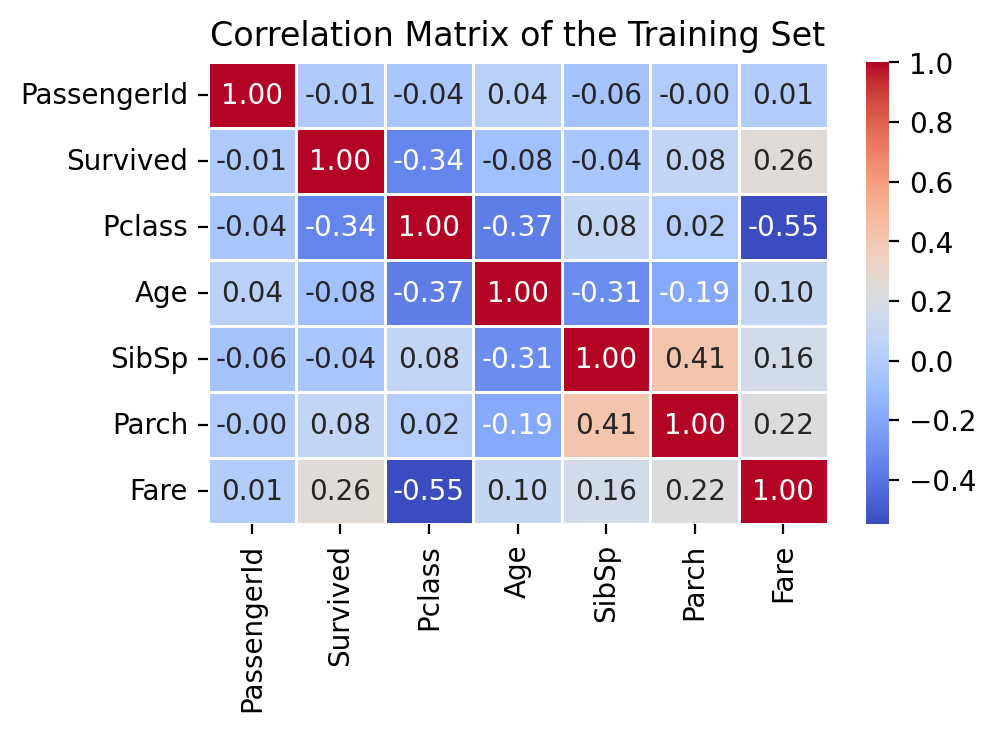

In [9]:
# Creation of a heatmap to visualize the Correlation Matrix 

plt.figure(figsize=(5,3),dpi=200)

sns.heatmap(train.corr(numeric_only=True),
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=.5)    

plt.title('Correlation Matrix of the Training Set')
plt.show()

**Interpretation of the Full Correlation Heatmap:**


* **Feature vs. Target (`Survived`):**
    * `Pclass` shows a significant negative correlation with `Survived`, confirming lower class numbers (e.g., 1st class) are associated with higher survival.
    * `Fare` shows a noticeable positive correlation  with `Survived`, aligning with the `Pclass` result – higher fares likely correspond to higher classes and better survival odds.
    * `Parch` has a slight positive correlation,while `SibSp` has a slight negative one. The effect of family seems less strongly linear.
    * `Age` shows only a weak negative linear correlation with survival in this overall view.

* **Feature vs. Feature:**
    * `Pclass` and `Fare` exhibit a strong negative correlation as expected (higher class number means lower fare).
    * `Age` and `Pclass` show a moderate negative correlation suggesting older passengers tended to be in higher classes (lower Pclass number).
    * `SibSp` and `Parch` show a positive correlation,indicating they often increase together (larger families).

**Takeaways:** `Pclass` and `Fare` stand out as having the strongest linear associations with `Survived` among these numerical columns.

**It is worth noting that this heatmap only reflects *linear* relationships.**

## 3.5 Data Visualization - Numerical Columns

Having separated the numerical features (`Age`, `SibSp`, `Parch`, `Fare`) into the `train_num` DataFrame, we now visualize their individual distributions. Histograms are an excellent tool for this, as they show the frequency of values within specific bins, revealing the shape, central tendency, spread, and skewness of each numerical variable.

The following code iterates through each column in `train_num` and generates a distinct histogram for it using `seaborn.histplot`.

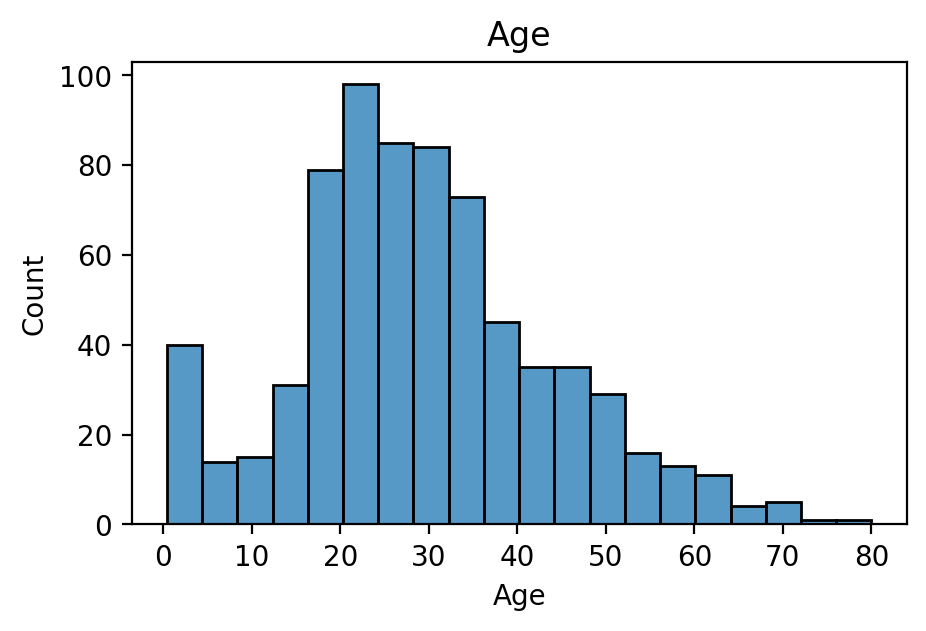

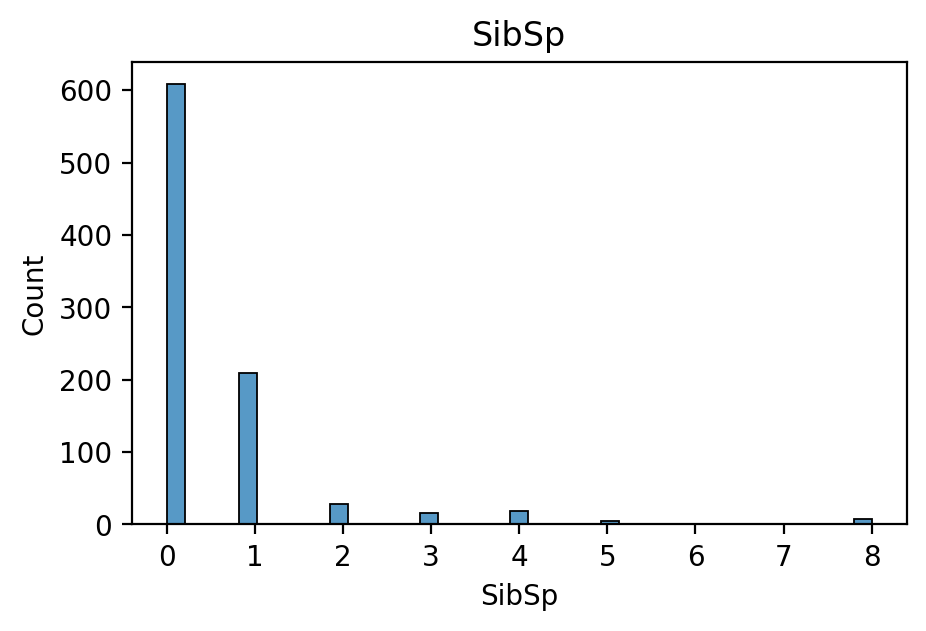

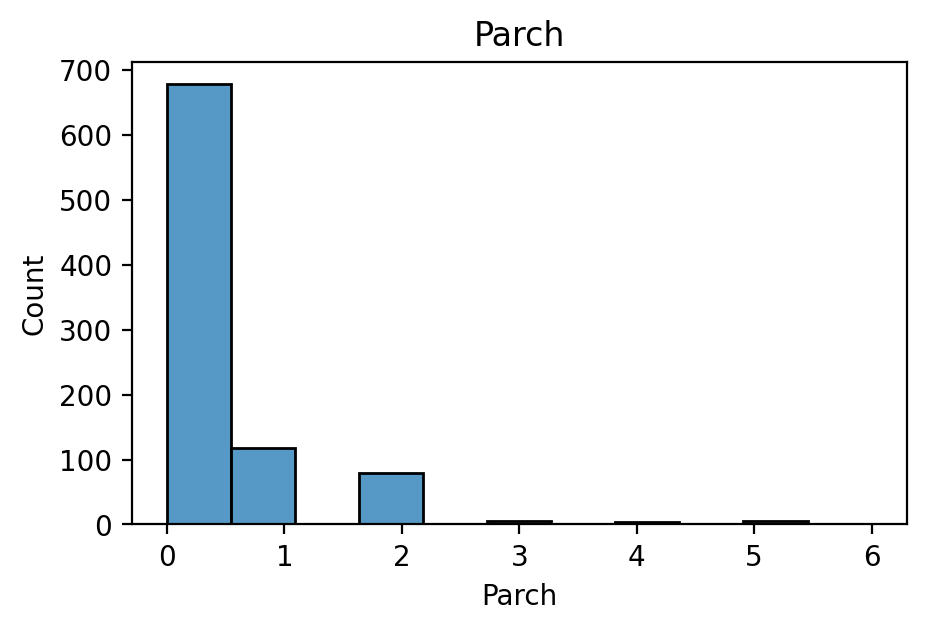

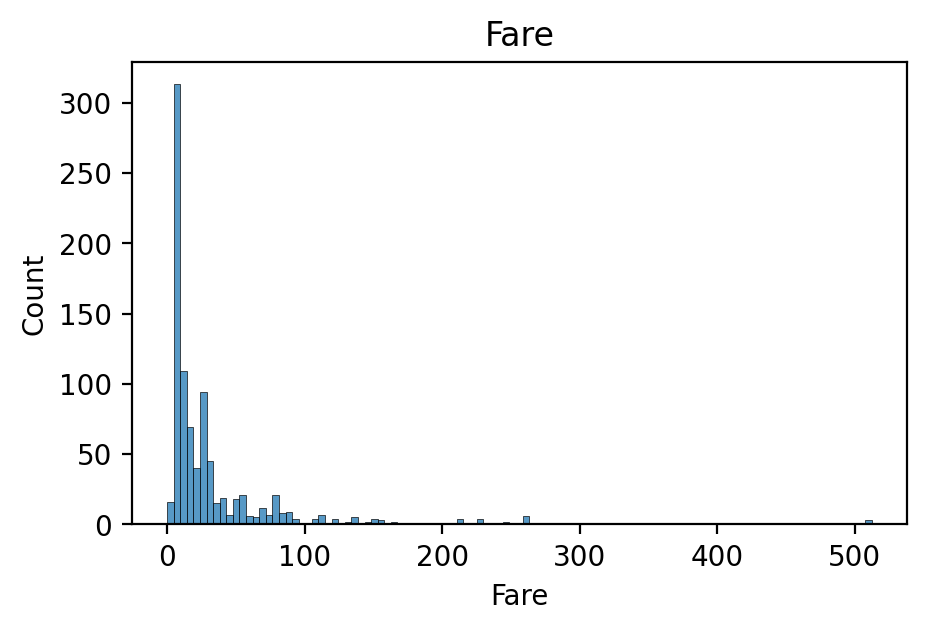

In [10]:
# I will plot our numeric and categorical columns seperately so that we can visualize the data more efficiently.

# Simple loop for plotting the distribution of each numerical column

for i in train_num.columns :
    plt.figure(figsize=(5,3),dpi=200)
    sns.histplot(train_num[i])
    plt.title(i)
    plt.show()
    

**Interpretation of Numerical Histograms:**

The series of histograms generated above provides visual confirmation of the characteristics seen in the `.describe()` output:

* **`Age`**: The histogram shows the distribution of passenger ages. We can observe that the distribution is roughly normal,ranging from near 0 to 80 and the bulk of passengers are between the 15-35 years old range.
* **`SibSp`**: This histogram confirms the strong right-skew. A large bar at 0 and a smaller one at 1 dominate, with frequencies dropping rapidly for higher counts of siblings/spouses.
* **`Parch`**: Similar to `SibSp`, the `Parch` histogram shows a strong right-skew, with the vast majority of passengers having 0 parents/children aboard.
* **`Fare`**: This plot illustrates the extreme right-skewness suggested by the statistics. Most fares are concentrated in the lower bins, while a very long tail extends far to the right due to a few very high fares. This visual strongly implies the need for a transformation (like log transform) before using `Fare` in machine learning models.

 

**Numerical Correlation Heatmap**

While the correlation matrix table provides exact values, a heatmap offers a much more intuitive visual representation of the linear relationships between our selected numerical features (`Age`, `SibSp`, `Parch`, `Fare`).

The following code calculates the correlation matrix for `train_num` and displays it using `seaborn.heatmap`. Color intensity and the annotated values indicate the strength and direction of the correlation (positive correlations tend towards red, negative towards blue).

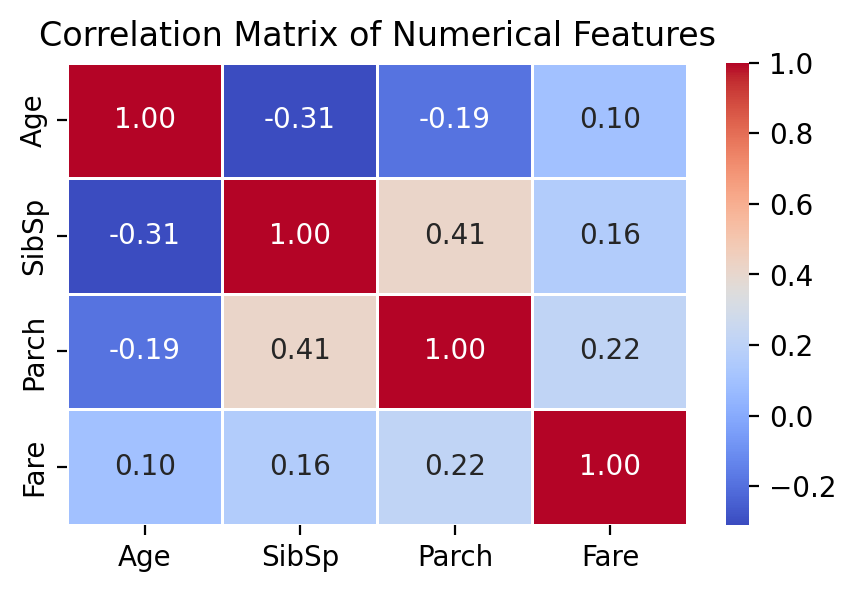

In [11]:
# Creation of a heatmap to visualize the correlations between our numerical columns.

plt.figure(figsize=(5,3),dpi=200)

sns.heatmap(train_num.corr(),
            annot=True,       
            cmap='coolwarm',  
            fmt=".2f",        
            linewidths=.5)    

plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Interpretation of Numerical Features Correlation Heatmap:**

This heatmap visualizes the relationships *among* the core numerical features:

* **Diagonal:** The bright red diagonal shows each variable perfectly correlating with itself (value 1.00).
* **`SibSp` & `Parch`:** There is a noticeable positive correlation  between the number of siblings/spouses (`SibSp`) and the number of parents/children (`Parch`). This makes logical sense, as these often combine to form larger family units traveling together.
* **Other Correlations:** The remaining correlations shown here (involving `Age` and `Fare` with each other and with `SibSp`/`Parch`) appear relatively weak. This suggests there isn't a strong *linear* relationship between age and fare, or between age/fare and the number of immediate family members aboard, within this subset.


Next, we should explore the categorical variables in `train_cat`.

## 3.6 Data Visualization - Categorical Features


### 3.6.1 Data Visualization - Derived 'Ticket' & 'Cabin' Features (vs. Count)

As noted during the initial data inspection, the raw `Ticket` and `Cabin` columns pose challenges for direct visualization due to high cardinality (`Ticket`) and extensive missing values/high cardinality (`Cabin`). Standard frequency plots of the original values would be uninformative or unreadable.

To overcome this and still extract potential insights during EDA, we perform a simple **feature engineering** step by creating new features based on the **first character** of each entry:

1.  **`Ticket_First_Character`**: We extract the very first character from each `Ticket` string. This groups tickets that share the same prefix (e.g., 'A', 'P', 'S', 'C') or start with the same digit ('1', '2', '3', etc.), potentially indicating different ticket types or blocks.
    
2.  **`Cabin_First_Character`**: Similarly, we extract the first character from the `Cabin` string. For passengers with a listed cabin, this typically represents the Deck level (e.g., 'A', 'B', 'C'). For the many passengers with missing (`NaN`) cabin data, converting the `NaN` to the string 'nan' and taking the first character results in the value 'n'. This conveniently creates a distinct category representing "missing/no cabin" information.

    **Note** : In the 'Cabin' plot we replace the 'n' value with 'No Cabin' in order to provide insight into what the value actually represents


    

Now that we have these simplified, derived features, we can visualize their frequency distributions using count plots to understand the prevalence of different ticket prefixes and cabin deck indicators (including the large 'n' category for missing cabins).

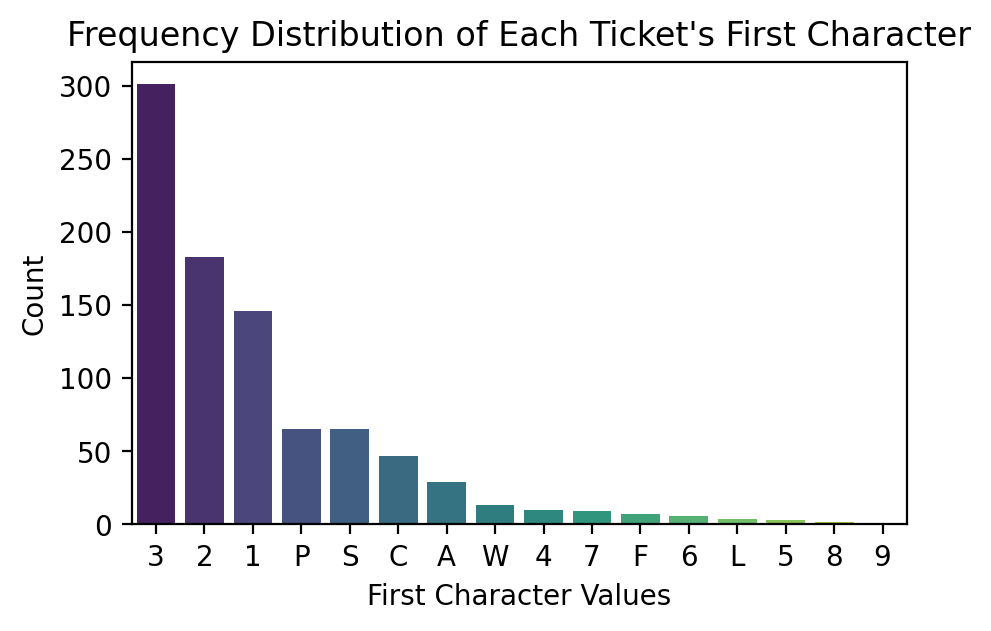

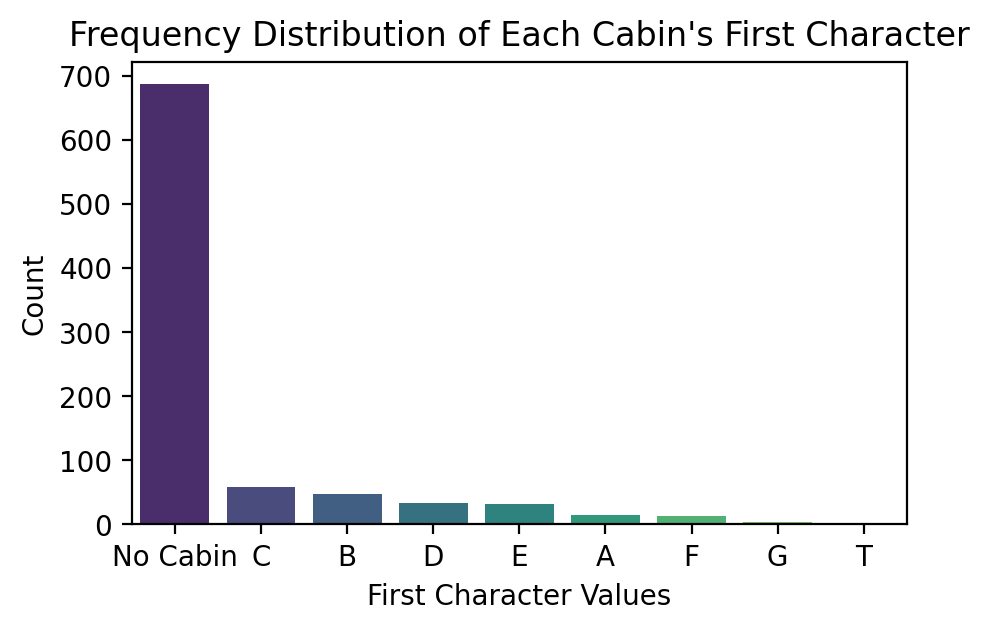

In [12]:
# Categorical columns visualization.
# We can't visualize the 'Cabin' and 'Ticket' columns effectively due to their high cardinality. Instead we are going to plot 'Cabin First Character' and 'Ticket First Character'. These features group the values with the same initial character and display them as a new value named after that character.
# The code for these features will be provided in the feature engineering section.

# First Character(feature engineering) 

train['Ticket_First_Character'] = train.Ticket.apply(lambda x:str(x)[0])
train['Cabin_First_Character'] = train.Cabin.apply(lambda x: str(x)[0])

#Tickets

ticket_col_name = 'Ticket_First_Character'
plt.figure(figsize=(5,3),dpi=200) 
sns.countplot(data=train,
              x=ticket_col_name,
              order=train[ticket_col_name].value_counts().index,
              palette='viridis')

plt.title("Frequency Distribution of Each Ticket's First Character")       
plt.xlabel("First Character Values")
plt.ylabel('Count')
plt.show()


#Cabins 
#Cabin_First_Letter marks as 'n'(from nan) the passengers without a Cabin. For clarity purposes I will replace the 'n' value with 'No Cabin' for the plot


cabin_col_name = 'Cabin_First_Character'
new_label_for_n = 'No Cabin'

plt.figure(figsize=(5,3),dpi=200) 

ax = sns.countplot(
        data=train,
        x=cabin_col_name,
        order=train[cabin_col_name].value_counts().index,
        palette='viridis')


#Replace the 'n' value with 'No Cabin' for clarification purposes

current_tick_labels = [label.get_text() for label in ax.get_xticklabels()]
new_tick_labels = [new_label_for_n if label == 'n' else label for label in current_tick_labels]
ax.set_xticklabels(new_tick_labels)

plt.title("Frequency Distribution of Each Cabin's First Character")
plt.xlabel("First Character Values")
plt.ylabel('Count')
plt.show()




**Interpretation of Derived Feature Plots:**


* **Ticket First Character Plot:**
    
    * Numerical digits (especially '3', '1', '2') are the most common starting characters.
    * Alphabetical prefixes like 'S', 'P', 'C', 'A' also appear frequently, while others are rare.
    * This distribution supports the feature engineering strategy of grouping the rarer starting characters (like those seen here with low counts) into an 'Other' category for modeling.

* **Cabin First Character Plot:**
    * The dominance of the **'No Cabin'** bar immediately confirms the large proportion of passengers with missing cabin information. This in itself is likely a useful feature.
    * Among passengers with known cabins, decks **'C', 'B', 'D', and 'E'** are visibly the most frequent.
    * Other decks like 'A', 'F', 'G' are confirmed to be much rarer in the training set.
    * This supports handling 'No Cabin' as a distinct category and grouping the rarer decks ('A', 'F', 'G', etc.) into an 'Other' category.



### 3.6.2 Data Visualization - 'Pclass' , 'Sex' , 'Embarked' columns
We now visualize the frequency distributions for the core categorical features identified earlier: `Pclass` (Passenger Class), `Sex`, and `Embarked` (Port of Embarkation).

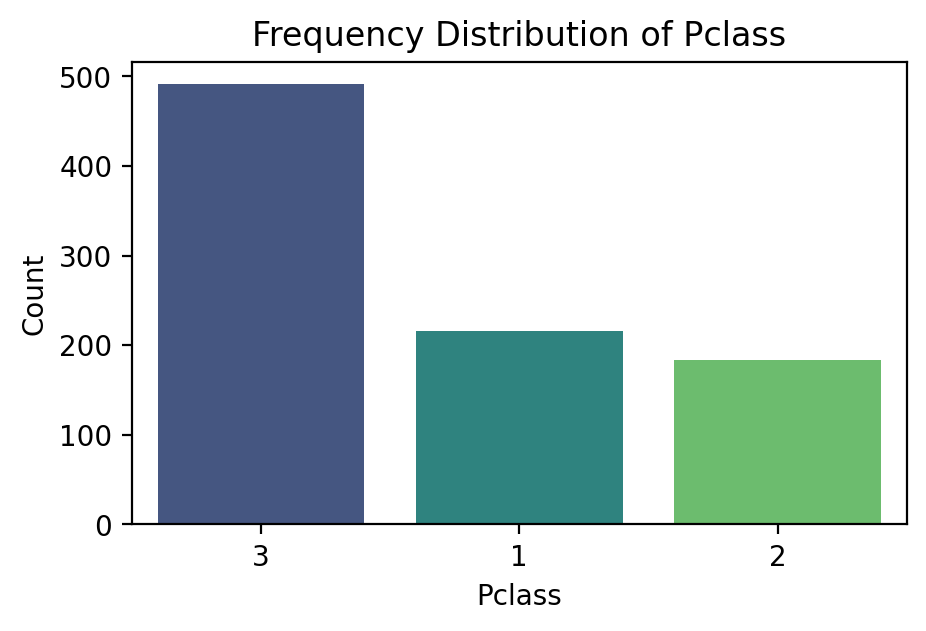

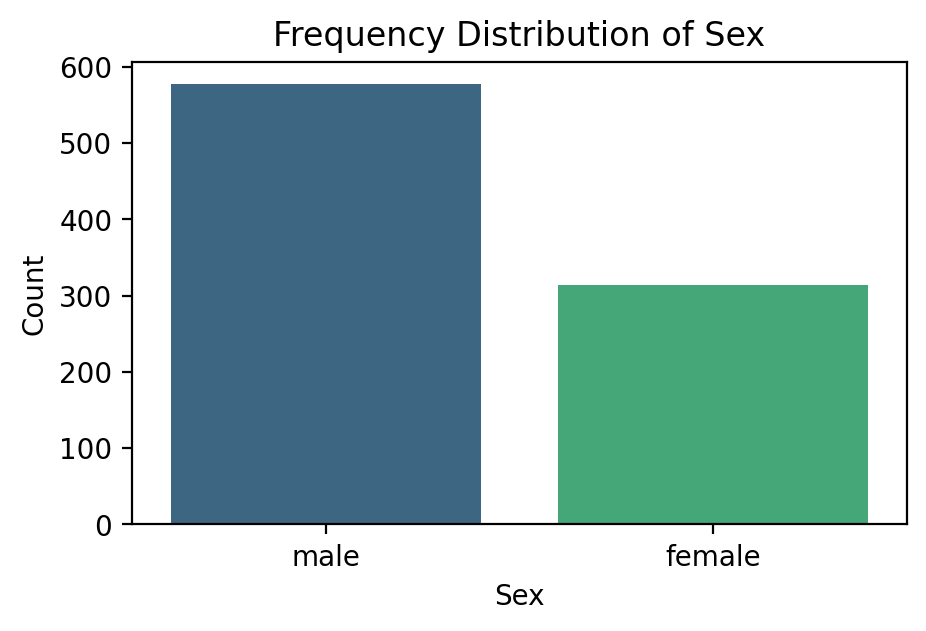

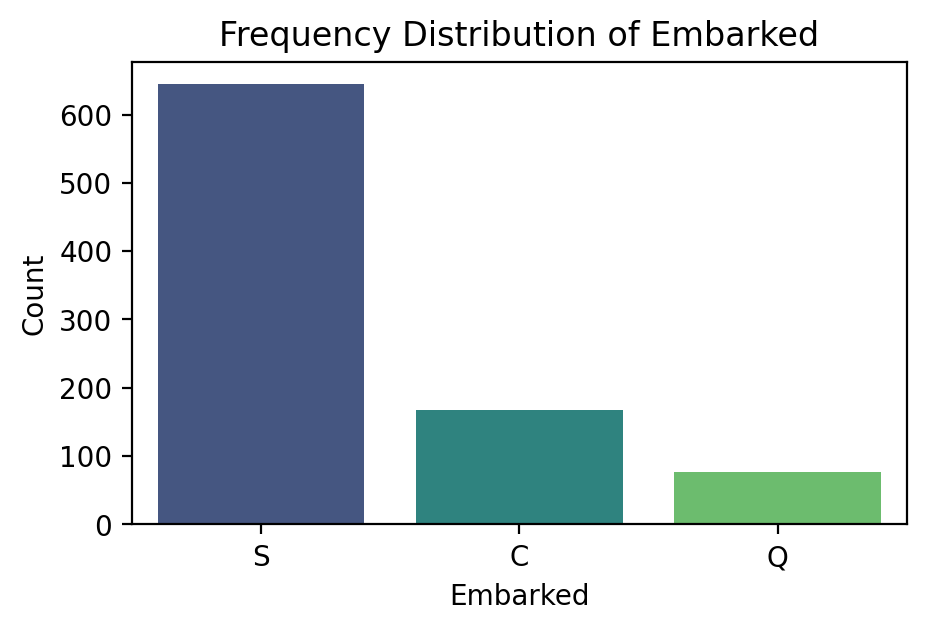

In [13]:
# Plotting the remaining categorical columns (Pclass,Sex,Embarked)

cols_to_plot = ['Pclass', 'Sex', 'Embarked']
for col in cols_to_plot:
    plt.figure(figsize=(5, 3),dpi=200) 
    
    sns.countplot(data=train, x=col,
                  order = train[col].value_counts().index,
                  palette='viridis') 
    plt.title(f'Frequency Distribution of {col}')
    plt.ylabel('Count')
    plt.show() 


**Interpretation of The Three Remaining Categorical Plots:**

* **`Pclass`**: We can visually confirm the distribution seen in the statistics: Class 3 is the largest group, followed by Class 1, with Class 2 having the fewest passengers.
* **`Sex`**: The plot clearly shows the imbalance between sexes noted earlier, with significantly more 'male' passengers than 'female' passengers in the training dataset.
* **`Embarked`**: This confirms 'S'(Southampton) as the overwhelmingly dominant port of embarkation, followed by 'C' (Cherbourg) and then 'Q' (Queenstown)..

## 3.7 Data Visualization - Visualizing Key Feature Relationships with Survival


Having examined the individual distributions of our features (both numerical and categorical), we now want to focus specifically on how these features relate to our target variable, `Survived`. Visualizing these relationships is key to identifying potentially strong predictors for our machine learning models.

**Selecting Features for Survival Analysis:**

Based on the insights gathered from the initial exploration steps (`.info()`, `.describe()`, `.corr()`, histograms, and count plots):

* The correlation matrix and heatmap highlighted **`Pclass`** and **`Fare`** as having significant linear correlations with `Survived`.
* Descriptive statistics and count plots showed **`Sex`** has a highly skewed distribution towards males, and general knowledge suggests gender was a critical survival factor.
* **`Embarked`** showed distinct categories with varying frequencies, and its relationship with survival is worth investigating further (potentially linked to Pclass/Fare).
* While **`Age`** had a weak overall linear correlation, its distribution and the "women and children first" historical context make its relationship with survival crucial to visualize directly.
* Engineered features like **`Ticket_First_Character`** and **`Cabin_First_Character`** capture important derived information that warrants investigation against the `Survived` outcome.



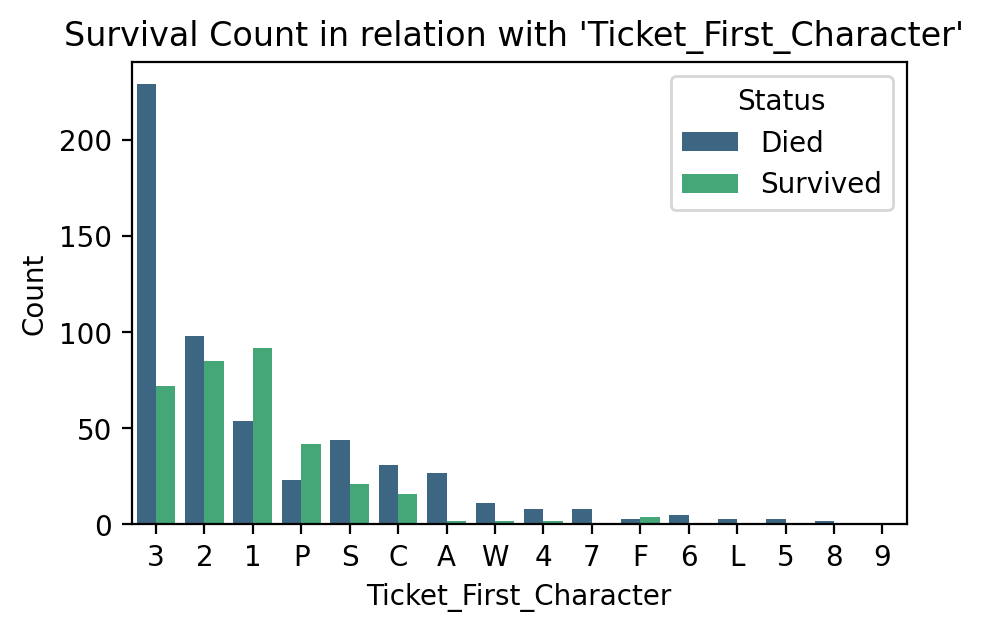

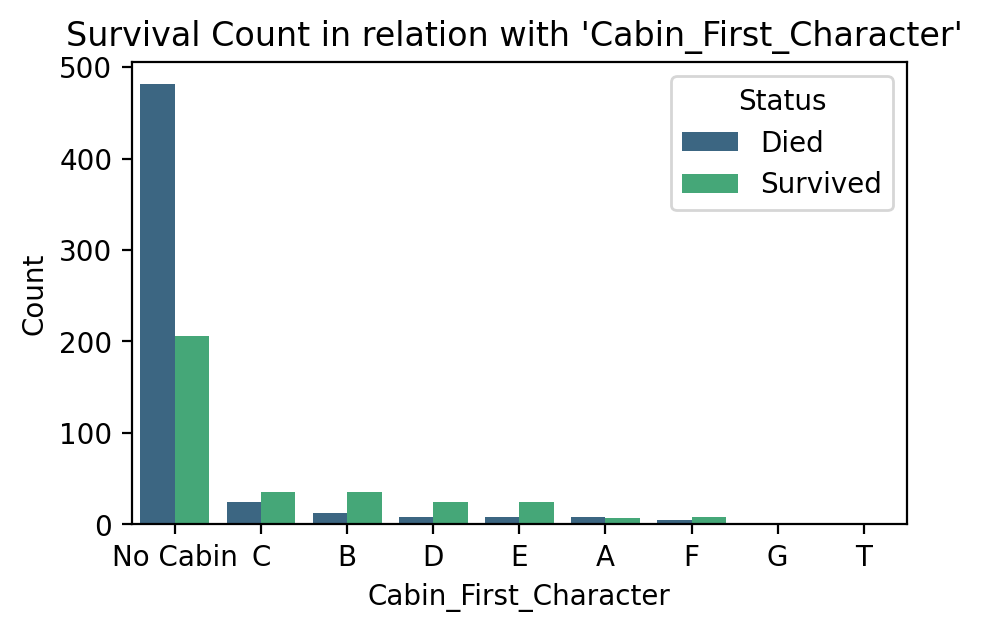

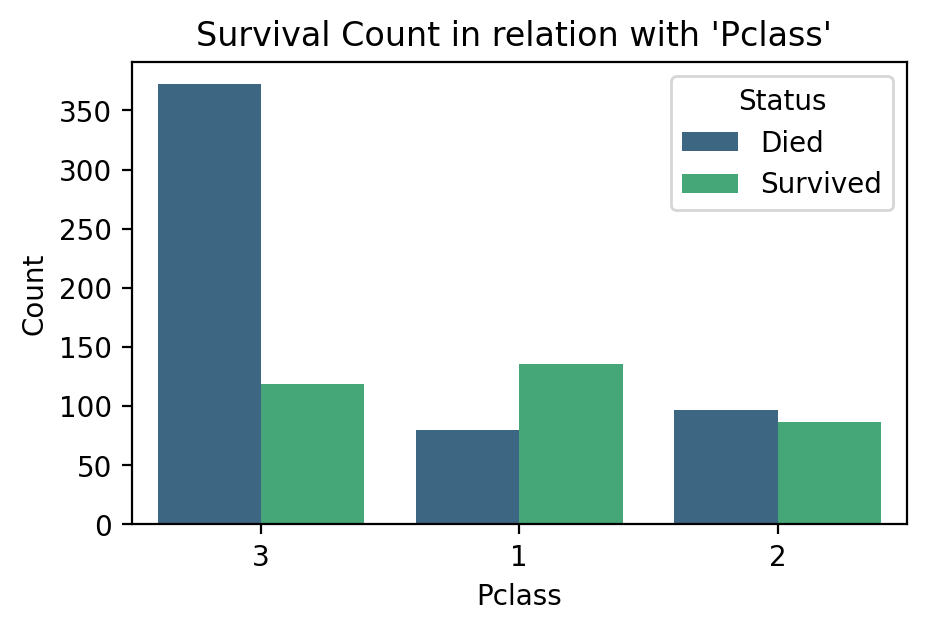

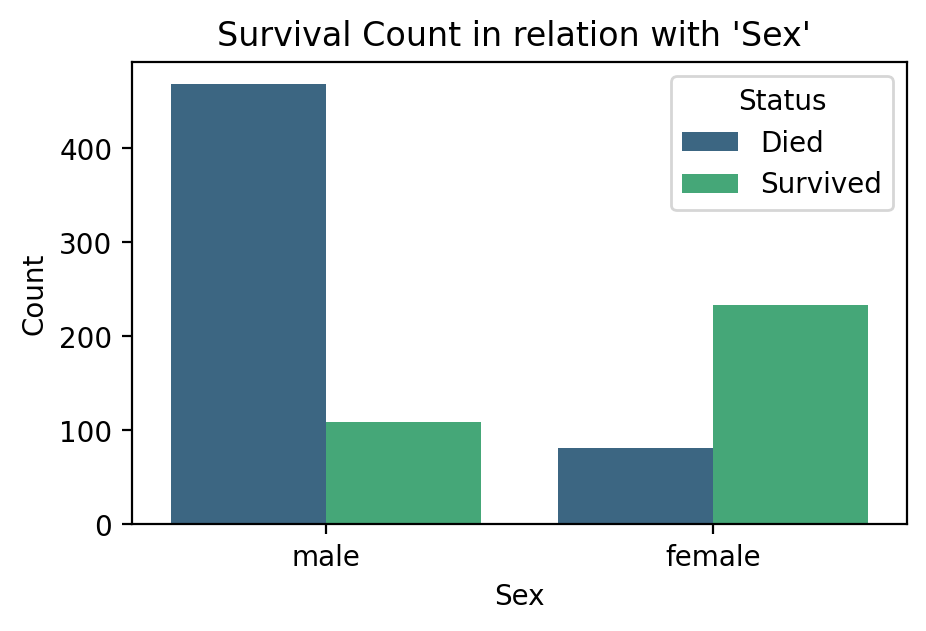

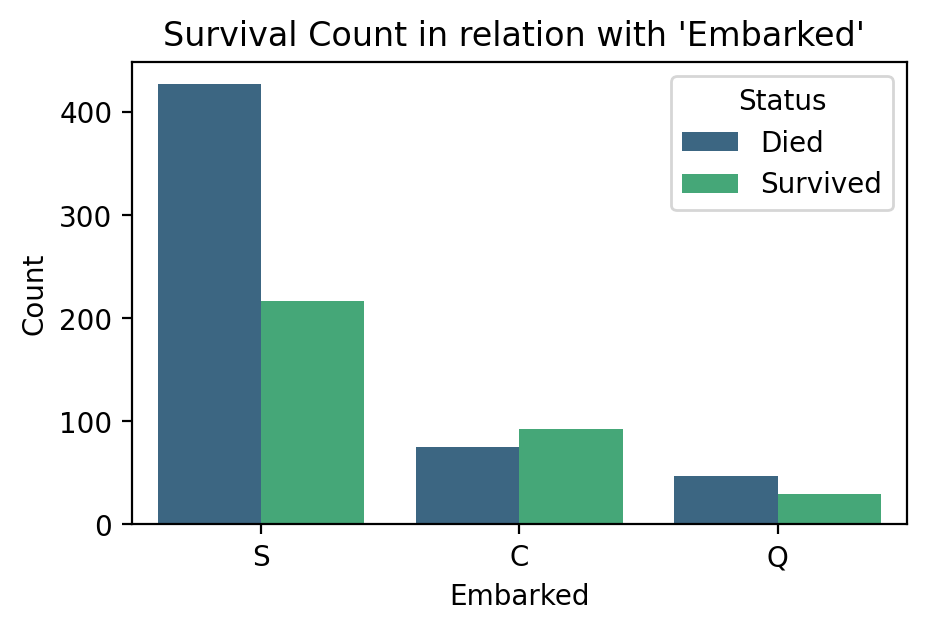

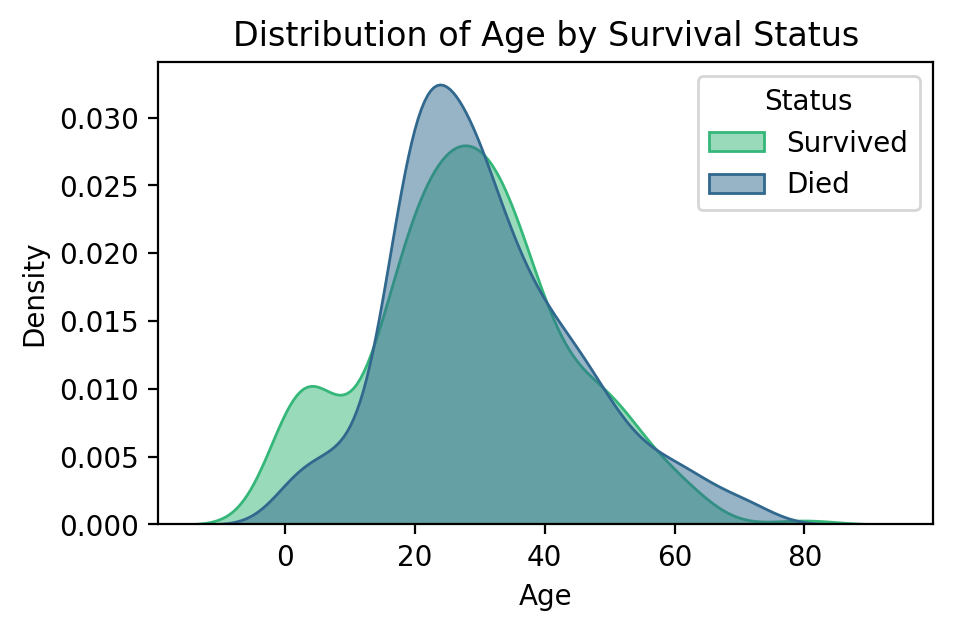

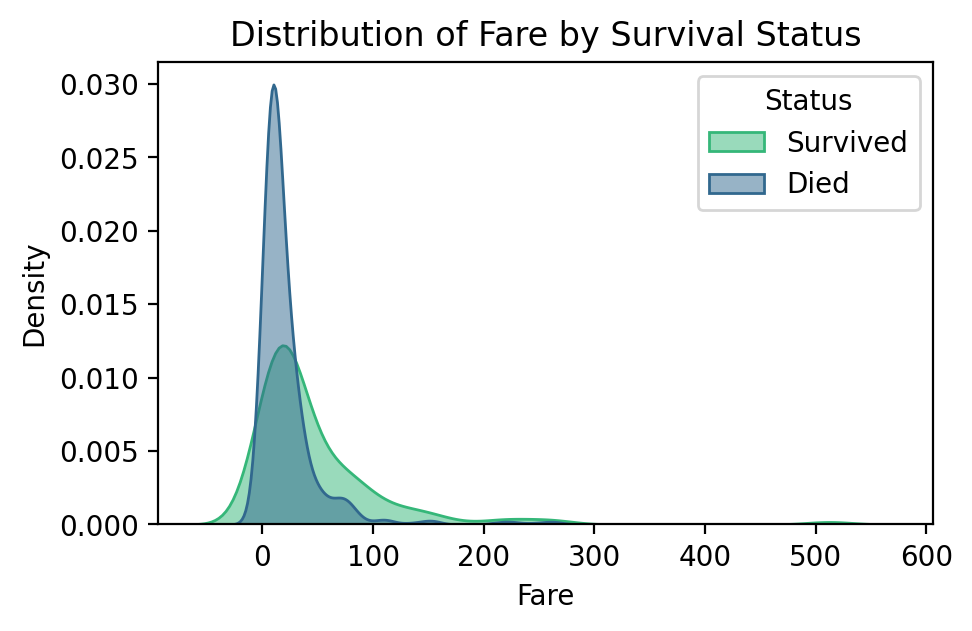

In [14]:
# Categorical vs Survived plots

cat_vs_survived = ['Ticket_First_Character','Cabin_First_Character','Pclass','Sex','Embarked']

for col in cat_vs_survived :
    
    plt.figure(figsize=(5,3),dpi=200)
    
    if col == 'Cabin_First_Character' : # Special case for Cabin_First_Character as we need to replace the 'n' with 'No Cabin'
        new_label_for_n = 'No Cabin'
        ax = sns.countplot(data = train,
                           x = col,
                           order = train[col].value_counts().index,
                           palette = 'viridis',
                           hue = 'Survived'
                           )
        
        current_tick_labels = [label.get_text() for label in ax.get_xticklabels()]
        new_tick_labels = [new_label_for_n if label == 'n' else label for label in current_tick_labels]
        ax.set_xticklabels(new_tick_labels)
        
        plt.xlabel(col)
        plt.title(f"Survival Count in relation with '{col}' ")
        plt.ylabel('Count')
        plt.legend(title='Status', loc='upper right', labels=['Died', 'Survived'])
        plt.show()
        
      
    
    else :
        sns.countplot(data = train,
                      x = col,
                      order = train[col].value_counts().index,
                      palette = 'viridis',
                      hue = 'Survived')
        
        plt.xlabel(col)
        plt.title(f"Survival Count in relation with '{col}' ")
        plt.ylabel('Count')
        plt.legend(title='Status', loc='upper right', labels=['Died', 'Survived'])
        plt.show()

# Numerical vs Survived plots 

numerical_vs_survived = ['Age', 'Fare']

for col in numerical_vs_survived:
    plt.figure(figsize=(5,3),dpi=200)
    sns.kdeplot(data = train, 
                x = col, 
                hue = 'Survived',
                fill = True, 
                common_norm = False, 
                palette = 'viridis', 
                alpha = 0.5) 
    plt.title(f'Distribution of {col} by Survival Status')
    plt.legend(title='Status', labels=['Survived','Died'])
    plt.show()

**Interpretation of Feature vs. Survival Plots:**

These visualizations, comparing key features against the `Survived` outcome, reveal strong predictive signals:


* **`Ticket_First_Character` vs Survival:** Highlights that certain prefixes (e.g., 'P', 'F', '1') tend to show higher survival proportions than others (e.g., 'S', 'A', '3'), supporting the use of this engineered feature.
* **`Cabin_First_Character` vs Survival:** Dramatically illustrates the low survival rate for passengers with 'No Cabin' compared to significantly higher rates for those on certain decks (e.g., 'B', 'D', 'E'). This confirms the predictive power of having cabin information and the deck level.
* **`Pclass` vs Survival:** Confirms the clear trend seen in correlations - survival rates decrease significantly from Class 1 to Class 3. Class is a strong indicator.
* **`Sex` vs Survival:** Shows the dramatic difference in survival rates, with 'female' passengers having a much higher chance of survival than 'male' passengers. This is arguably the strongest single predictor.
* **`Embarked` vs Survival:** Highlights differing survival rates by port, with 'C' (Cherbourg) showing the highest rate, after a quick online search it seems that this specific port has a higher proportion of first-class passengers embarking there. 'S' (Southampton) shows the lowest rate.
* **`Age` vs Survival :** The distributions differ noticeably. Non-survivors show a larger peak in the young adult to middle-age range. Survivors  have a more prominent peak at very young ages (children) and differ in other age ranges, reflecting the "children first" aspect.
* **`Fare` vs Survival :** The distribution density for survivors is clearly shifted towards higher fares compared to non-survivors, reinforcing that passengers who paid more (likely higher class) had better survival odds. 

**Overall EDA Conclusion:** These visualizations strongly indicate that `Sex`, `Pclass`, `Fare`, `Cabin` information , and `Age` are key drivers of survival prediction. `Embarked` and `Ticket_First_Letter` also show clear relationships with the outcome. This visual analysis guides our feature engineering and confirms the importance of the features selected or derived for modeling.

# **4. Feature Engineering**


Now that we have explored the raw data (EDA), we begin the **Feature Engineering** phase. The goal here is to clean, transform, and create features that will be most effective for our machine learning models. This involves several steps, starting with handling the missing values identified previously.



## 4.1 Feature Engineering - Handling Missing Values (Embarked & Age)

Our EDA (`.info()`) showed missing values primarily in `Age` (177), `Cabin` (687), and `Embarked` (2).

* For **`Embarked`**, since only 2 values are missing, we can confidently fill them using the most frequent value (mode) without significantly impacting the feature's distribution.
* For **`Age`**, dropping ~20% of the data is undesirable. We'll use a simple imputation strategy here: filling the missing values with the **mean** age calculated from the training set. This ensures all passengers have an age value.

The following code implements the mode imputation for `Embarked` and mean imputation for `Age`, applying the values learned from the `train` set consistently to both `train` and `test` sets. After the changes are made we also perform a check to see if there are any missing values still present on our `Embarked` and `Age` columns.

In [15]:
# FEATURE ENGINEERING : Cleaning up data , Filling missing values, Dropping rows, etc.

# From train.info() we saw that 'Embarked' has only 2 missing values so I will use mode() to find the most frequent port and replace them.

embarked_mode = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(embarked_mode)
test['Embarked'] = test['Embarked'].fillna(embarked_mode)

# Regarding the 'Age' missing values , we will fill the missing values with the age mean.

mean_age = train['Age'].mean()
train['Age'] = train['Age'].fillna(mean_age)
test['Age'] = test['Age'].fillna(mean_age)

#Check if 'Embarked' has any missing values

print(f" Number of missing values in the 'Embarked' column of the training dataset  : {train['Embarked'].isnull().sum()}")
print(f" Number of missing values in the 'Embarked' column of the test dataset  : {test['Embarked'].isnull().sum()}")
print('\n')

#Check if 'Age' has any missing values

print(f" Number of missing values in the 'Age' column of the training dataset  : {train['Age'].isnull().sum()}")
print(f" Number of missing values in the 'Age' column of the test dataset  : {test['Age'].isnull().sum()}")

 Number of missing values in the 'Embarked' column of the training dataset  : 0
 Number of missing values in the 'Embarked' column of the test dataset  : 0


 Number of missing values in the 'Age' column of the training dataset  : 0
 Number of missing values in the 'Age' column of the test dataset  : 0


## 4.2 Feature Engineering - Cabin: First Character Extraction & Grouping


We now address the `Cabin` column, which has many missing values and varied entries. Our strategy here is twofold, implemented together in the next code cell:

1.  **Extract First Character:** We first derive a `Cabin_First_Character` feature. This captures the deck letter (like 'A', 'B', 'C') for known cabins. Importantly, this step also handles the numerous missing (`NaN`) values by converting them to the string 'nan' and taking the first letter, resulting in a distinct 'n' category representing "no cabin listed". 
2.  **Group Rare Characters:** We then analyze the frequencies of these first characters *in the training set*. Characters that appear very rarely (e.g., fewer than 20 times) are grouped into a single 'Other' category. This creates a final, cleaner feature called `Cabin_Character_Group`, reducing noise from rare instances while keeping the main deck categories and the 'n' (missing) category distinct. This grouping rule, learned from `train`, is applied consistently to both `train` and `test`.

The code cell below performs both the extraction and grouping, then shows the final value counts for `Cabin_Character_Group` as verification.

**Note:**  In our final datasets we will **drop** the column `Cabin_First_Character` as it will be redundant with `Cabin_Character_Group` present.

In [16]:
# Let's group the Cabins by their first character as it is logical that those sharing one will be approximate to eachother or in the same deck. # Drop for final df

train['Cabin_First_Character'] = train.Cabin.apply(lambda x: str(x)[0])
test['Cabin_First_Character'] = test.Cabin.apply(lambda x: str(x)[0])

# the 'n' stands for 'nan' and we will use it as it's own category.

print(f"Value Counts from the train dataset for : {train['Cabin_First_Character'].value_counts()}")
print("\n" f"Value Counts from the test dataset for: {test['Cabin_First_Character'].value_counts()}")


#I will group the cabins that have a low value count.(<20)

cabin_char_values = train['Cabin_First_Character'].value_counts()
low_cabin_char_values = cabin_char_values[cabin_char_values < 20].index.tolist() 

#Let's create a new column which will have the original values with the exception of the low-count values, as they will be grouped as 'Other'

train['Cabin_Character_Group'] = train['Cabin_First_Character']
test['Cabin_Character_Group'] = test['Cabin_First_Character']
train.loc[train['Cabin_First_Character'].isin(low_cabin_char_values), 'Cabin_Character_Group'] = 'Other'
test.loc[test['Cabin_First_Character'].isin(low_cabin_char_values), 'Cabin_Character_Group'] = 'Other'

#Check to see if it's working

print("\nFinal value counts (after grouping the low count Cabins) from the train dataset:")
print(train['Cabin_Character_Group'].value_counts())
print("\nFinal value counts (after grouping the low count Cabins) from the test dataset:")
print(test['Cabin_Character_Group'].value_counts())

#Numerical Confirmation of the Cabin Character Group vs Survived plot

print("\nSurvival Rate by Cabin_Character_Group from the train dataset (sorted by Mean Survival Rate):")
print(train.groupby('Cabin_Character_Group')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))


Value Counts from the train dataset for : Cabin_First_Character
n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

Value Counts from the test dataset for: Cabin_First_Character
n    327
C     35
B     18
D     13
E      9
F      8
A      7
G      1
Name: count, dtype: int64

Final value counts (after grouping the low count Cabins) from the train dataset:
Cabin_Character_Group
n        687
C         59
B         47
Other     33
D         33
E         32
Name: count, dtype: int64

Final value counts (after grouping the low count Cabins) from the test dataset:
Cabin_Character_Group
n        327
C         35
B         18
Other     16
D         13
E          9
Name: count, dtype: int64

Survival Rate by Cabin_Character_Group from the train dataset (sorted by Mean Survival Rate):
                           mean  count
Cabin_Character_Group                 
D                      0.757576     33
E                      0.750000     32
B 

**Cabin First Character Grouping Completed**

1.  The intermediate `Cabin_First_Character` feature was created, successfully capturing deck letters and representing missing values as 'n'.
2.  Rare deck characters (appearing fewer than 20 times in `train`, e.g., ['T', 'G', 'F', 'A']) were identified based on the initial value counts.
3.  The final `Cabin_Character_Group` feature was generated by consolidating these rare decks into an 'Other' category, applied consistently across `train` and `test`.
4.  The groupby numerically confirms our earlier findings between Cabin Character Group and Survived

`Cabin_Character_Group` now contains the large 'n' category, the more frequent deck categories (B, C, D, E), and the new 'Other' category. This feature provides a balanced categorical representation of cabin information suitable for one-hot encoding.

## 4.3 Feature Engineering - `Cabin_Multiple` Feature


We can also investigate if the *number* of cabins assigned to a passenger holds predictive value. Some passengers have multiple cabins listed (e.g., "C23 C25 C27"), which might indicate higher status or family groupings not captured elsewhere.

The following code block engineers a feature called `Cabin_Multiple` to capture this:
1.  It first counts the number of space-separated cabin entries for each passenger (assigning 0 if the original `Cabin` was NaN).
2.  Recognizing that having 2, 3, or 4 cabins is rare, it bins these counts, grouping all passengers with 2 or more cabins into a single category '2'. The feature now represents: **0 = No Cabin Listed, 1 = Single Cabin Listed, 2 = Multiple (2+) Cabins Listed.**
3.  Finally, it displays a pivot table to show the relationship between this new categorical feature and `Survived`.

In [17]:
# Firstly we need to check if there are passengers with multiple cabins as it may correlate with survival rate:

train['Cabin_Multiple'] = train.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
test['Cabin_Multiple'] = test.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))

print(f"Value counts for initial {train['Cabin_Multiple'].value_counts()}")

#Let's bin the small value counts together. The values : ('2','3','4') will be replaced with '2'.It will be treated as a categorical feature with '2' indicating multiple cabins

train.loc[train['Cabin_Multiple'] >= 2 , 'Cabin_Multiple'] = 2
test.loc[test['Cabin_Multiple'] >= 2 , 'Cabin_Multiple'] = 2

print("\n"f"Value counts (after binning) for {train['Cabin_Multiple'].value_counts()}")


#Checking the correlation between survival rate and multiple cabins:

print("\nCounts of Survived vs Binned Cabin_Multiple:")
print(pd.pivot_table(train,index='Survived',columns = 'Cabin_Multiple',values = 'Ticket',aggfunc='count'))

Value counts for initial Cabin_Multiple
0    687
1    180
2     16
3      6
4      2
Name: count, dtype: int64

Value counts (after binning) for Cabin_Multiple
0    687
1    180
2     24
Name: count, dtype: int64

Counts of Survived vs Binned Cabin_Multiple:
Cabin_Multiple    0    1   2
Survived                    
0               481   58  10
1               206  122  14


**Interpretation of `Cabin_Multiple` Engineering and Analysis:**

The code successfully created the `Cabin_Multiple` feature, categorizing passengers based on whether they had no cabin listed (0), a single cabin (1), or multiple cabins (2+).

The pivot table showing counts against `Survived` gives us preliminary insights:
* **No Cabin (0):** This largest group appears to have a lower survival rate **(206/687 ≈ 30% survival rate)**.
* **Single Cabin (1):** This group shows a significantly higher survival rate **(122/180 ≈ 67% survival rate)**.
* **Multiple Cabins (2):** This small group also has a high survival rate but it has a very small sample size **(14/24 ≈ 58% survival rate)**.

This suggests that simply having *any* recorded cabin (single or multiple) compared to none is associated with better survival odds. This engineered feature captures this distinction and will be treated as a categorical variable (0, 1, 2) for modeling.

## 4.4 Feature Engineering - Handling the Ticket Column


The `Ticket` column, like `Cabin`, contains complex string information with many unique values, making it unsuitable for direct use in most models. Our initial EDA (e.g., `train['Ticket'].value_counts()`) revealed this high cardinality.

Our strategy to extract useful information mirrors the approach for `Cabin`:
1.  **Extract the First Character:** Create `Ticket_First_Character`, assuming the prefix/digit might group tickets meaningfully. We'll examine its distribution and relationship with survival.
2.  **Group Rare Characters:** Consolidate infrequent first characters (based on training set counts) into an 'Other' category to create a final `Ticket_Character_Group` feature.

The first code block below creates the `Ticket_First_Character` and performs an initial analysis against `Survived` to inform the grouping strategy.

In [18]:
# Let's organize our tickets by their first letter or number as we did with the cabins.

train['Ticket_First_Character'] = train.Ticket.apply(lambda x:str(x)[0])
test['Ticket_First_Character'] = test.Ticket.apply(lambda x:str(x)[0])

print("Value counts for 'Ticket_First_Character'from the train dataset:")
print(train['Ticket_First_Character'].value_counts())
print("\nValue counts for 'Ticket_First_Character'from the test dataset:")
print(test['Ticket_First_Character'].value_counts())

#First_Ticket_Character vs 'Survived'

print("\nSurvival Rate by Ticket_First_Character from the train dataset (sorted by Mean Survival Rate):")
print(train.groupby('Ticket_First_Character')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))

Value counts for 'Ticket_First_Character'from the train dataset:
Ticket_First_Character
3    301
2    183
1    146
P     65
S     65
C     47
A     29
W     13
4     10
7      9
F      7
6      6
L      4
5      3
8      2
9      1
Name: count, dtype: int64

Value counts for 'Ticket_First_Character'from the test dataset:
Ticket_First_Character
3    128
2     95
1     64
S     33
P     33
C     30
A     13
W      6
F      6
7      4
6      3
4      1
9      1
L      1
Name: count, dtype: int64

Survival Rate by Ticket_First_Character from the train dataset (sorted by Mean Survival Rate):
                            mean  count
Ticket_First_Character                 
9                       1.000000      1
P                       0.646154     65
1                       0.630137    146
F                       0.571429      7
2                       0.464481    183
C                       0.340426     47
S                       0.323077     65
L                       0.250000      4
3     

**Analysis of Ticket First Character vs. Survival:**

The value counts show the different starting characters observed (digits '1'-'9', letters 'A', 'C', 'F', 'L', 'P', 'S', 'W', etc.) and their frequencies.

 The grouped analysis provide initial insights into potential relationships with survival:
* Different starting characters appear to have somewhat different average survival rates (`mean`).
* Several starting characters have very low counts in the training data (e.g., 'W', 'F', 'L', '5', '6', '7', '8', '9' have counts below 20). Basing survival estimates on these small groups is unreliable.

This analysis confirms that while the first character might hold some signal, grouping the low-count characters is a necessary step to create a more robust feature for modeling.

In [19]:
#Let's identify which first character value counts are lower 20.

ticket_character_counts = train['Ticket_First_Character'].value_counts()
low_count_characters = ticket_character_counts[ticket_character_counts < 20].index.tolist()

#Let's create the column which has the original values but merges the low count values together as 'Other'

train['Ticket_Character_Group'] = train['Ticket_First_Character']
test['Ticket_Character_Group'] = test['Ticket_First_Character']
train.loc[train['Ticket_First_Character'].isin(low_count_characters), 'Ticket_Character_Group'] = 'Other'
test.loc[test['Ticket_First_Character'].isin(low_count_characters), 'Ticket_Character_Group'] = 'Other'

#Verify it's working and print Ticket_Character_Group

print("Final value counts for 'Ticket_Character_Group' from the train dataset:")
print(train['Ticket_Character_Group'].value_counts())
print("\nFinal value counts for 'Ticket_Character_Group' from the test dataset:")
print(test['Ticket_Character_Group'].value_counts())

#Ticket_Character_Group vs 'Survived'
print("\nSurvival Rate by Ticket_Character_Group from the train dataset (sorted by Mean Survival Rate):")
print(train.groupby('Ticket_Character_Group')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))

Final value counts for 'Ticket_Character_Group' from the train dataset:
Ticket_Character_Group
3        301
2        183
1        146
P         65
S         65
Other     55
C         47
A         29
Name: count, dtype: int64

Final value counts for 'Ticket_Character_Group' from the test dataset:
Ticket_Character_Group
3        128
2         95
1         64
S         33
P         33
C         30
Other     22
A         13
Name: count, dtype: int64

Survival Rate by Ticket_Character_Group from the train dataset (sorted by Mean Survival Rate):
                            mean  count
Ticket_Character_Group                 
P                       0.646154     65
1                       0.630137    146
2                       0.464481    183
C                       0.340426     47
S                       0.323077     65
3                       0.239203    301
Other                   0.218182     55
A                       0.068966     29


**Ticket Character Grouping Complete:**

We have succesfully identified the first characters appearing fewer than 20 times in the training set and consolidated them into an 'Other' category within the new `Ticket_Character_Group` feature. This was applied consistently to both `train` and `test`.

The final value counts show the distribution across the more frequent starting characters (like '1', '2', '3', 'S', 'P', 'C', 'A') and the combined 'Other' group. This provides a simplified categorical feature derived from the complex `Ticket` information, ready for one-hot encoding later.
What is more, the final table confirms our visual intepretations of the Ticket Character Groups in relation to Survival.

**Note:** Similarly to `First_Cabin_Character`, `First_Ticket_Character` will be **replaced** in the final dataframe by `Ticket_Character_Group`

## 4.5 Feature Engineering and Data Visualization - Family Features (`FamilySize`,`IsAlone`)

### 4.5.1 Feature Engineering - Family Features (`FamilySize`, `IsAlone`)

I hypothesize that Family Size is very likely to influence the survival of the passengers. Using the `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) columns, we engineer two related features:

1.  **`FamilySize`**: A numerical count calculated as `SibSp + Parch + 1` (including the passenger).
2.  **`IsAlone`**: A binary flag (1 if `FamilySize` is 1, 0 otherwise) to specifically capture passengers travelling alone.



In [20]:
#It makes sense to create a new column 'FamilySize' using the existing columns 'SibSp' and 'Parch' as it will probably have a correlation with Survival rate.

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

#Let's also add another column 'IsAlone' to make perchance correlations clearer (its the same as train['FamilySize'] == 1)

train['IsAlone'] = 0
train.loc[train['FamilySize'] == 1,'IsAlone'] = 1
test['IsAlone'] = 0
test.loc[test['FamilySize'] == 1,'IsAlone'] = 1

#Check (FamilySize = 1 should equal IsAlone = 1 and FamilySize > 1 should equal IsAlone = 0)

print("\nValue counts for 'FamilySize':")
print(train['FamilySize'].value_counts())
print('\nValue counts for \'IsAlone\':')
print(train['IsAlone'].value_counts())



Value counts for 'FamilySize':
FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

Value counts for 'IsAlone':
IsAlone
1    537
0    354
Name: count, dtype: int64


**Family Features Created:**

* **`FamilySize`**: Shows that traveling alone (`FamilySize`=1) is the most common scenario, followed by smaller family sizes (2, 3, 4). Larger families exist but are much less frequent.
* **`IsAlone`**: Quantifies the number of solo travelers (`IsAlone`=1) versus those with family (`IsAlone`=0), confirming that solo travelers constitute the majority group.

Next up, we should check if these features have any links to survival rate.

### 4.5.2 Data Visualization - Family Features vs. Survival



Now that we have created `FamilySize` and the binary `IsAlone` feature, let's visualize their relationship with the `Survived` target variable to see if they exhibit predictive patterns. We expect family structure to influence survival outcomes.

We will use:
* A count plot for `IsAlone` split by `Survived`.
* A box plot comparing the distribution of `FamilySize` for survivors versus non-survivors.
* A numerical summary using `groupby()` for precise rates.

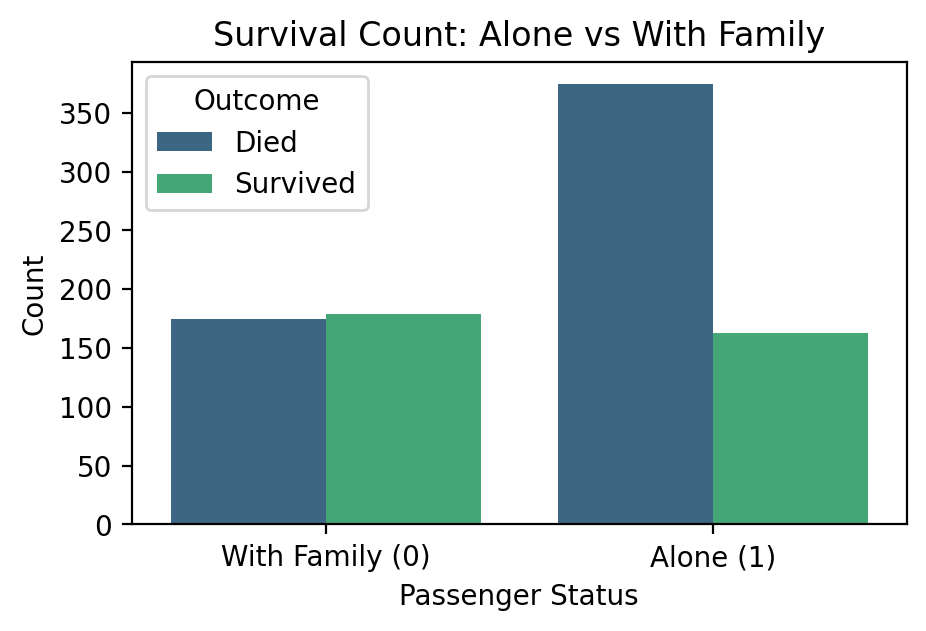

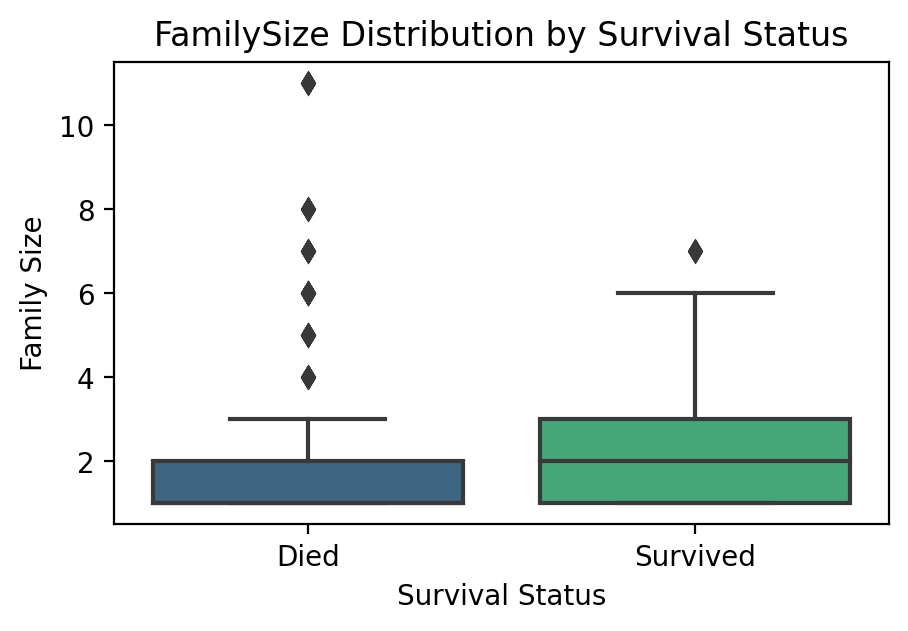


Survival Rate by IsAlone:
             mean  count
IsAlone                 
0        0.505650    354
1        0.303538    537

Survival Rate by FamilySize:
                mean  count
FamilySize                 
4           0.724138     29
3           0.578431    102
2           0.552795    161
7           0.333333     12
1           0.303538    537
5           0.200000     15
6           0.136364     22
8           0.000000      6
11          0.000000      7


In [21]:
#Countplot IsAlone vs Survived 

plt.figure(figsize=(5, 3),dpi=200)
sns.countplot(data=train, x='IsAlone', hue='Survived', palette='viridis')
plt.title('Survival Count: Alone vs With Family')
plt.xlabel('Passenger Status') 
plt.ylabel('Count')
plt.xticks([0, 1], ['With Family (0)', 'Alone (1)']) 
plt.legend(title='Outcome', labels=['Died', 'Survived']) 
plt.show()

#Boxplot Survived vs FamilySize

plt.figure(figsize=(5, 3),dpi=200)
sns.boxplot(data=train, x='Survived', y='FamilySize', palette='viridis')
plt.title('FamilySize Distribution by Survival Status')
plt.xlabel('Survival Status')
plt.xticks([0, 1], ['Died', 'Survived']) 
plt.ylabel('Family Size')
plt.show()

#Groupby

print("\nSurvival Rate by IsAlone:")
print(train.groupby('IsAlone')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))

print("\nSurvival Rate by FamilySize:")
print(train.groupby('FamilySize')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))



**Interpretation of Family Features vs. Survival Analysis:**

* **`IsAlone` vs Survival:** The count plot shows the survival counts for passengers who were alone (`IsAlone=1`) versus those with family (`IsAlone=0`). By comparing the proportion of survivors within each group the survival rate appear **lower** for those who were alone compared to those with family .
* **`FamilySize` vs Survival:** The box plot compares the distribution of `FamilySize` for survivors and non-survivors.The median family size seems **higher** for survivors, suggesting small families (size 2-4) might have had an advantage over solo travelers or very large families.
*  The `groupby` tables provides the exact mean survival rates : We observe that the `mean` survival rate for those traveling solo **(~30%)** is almost half of those traveling with family **(~50%)**, which is an insightful correlation. We also see the highest survival rate not for `FamilySize=1` nor for very large families, but for small family units (sizes 2, 3, 4). Lastly, it is numerically confirmed that very large families (5+) showed poor survival rates.

These results confirm that `FamilySize` and `IsAlone` capture information relevant to survival, likely reflecting factors like women and children being prioritized, or the difficulties faced by very large families during the evacuation.

## 4.6 Feature Engineering - Extracting and Cleaning Titles from Names

The `Name` column, while unique for each passenger, contains titles (Mr., Mrs., Miss., Master., Capt., Dr., etc.) which can serve as valuable proxies for age, gender, social status, and potentially survival outcome. We will engineer a categorical `Title` feature from this information.

The process, executed in the code cell below, involves:
1.  **Extraction:** Using a regular expression to extract the title part from the full name string for both `train` and `test` sets.
2.  **Initial Review:** Displaying the counts of all raw titles extracted to understand the initial diversity and identify rare titles present (especially in the training set).
3.  **Cleaning & Grouping:** Normalizing variations (e.g., 'Mlle', 'Ms' -> 'Miss'; 'Mme' -> 'Mrs') and consolidating genuinely rare titles (like 'Dr', 'Rev', 'Col', 'Capt', 'Lady', 'Sir', 'Don', 'Dona', 'Countess', 'Jonkheer') into a single 'Rare' category. This simplification creates more robust categories for modeling and is applied consistently using a predefined list.
4.  **Verification:** Displaying the final counts of the cleaned `Title` categories in both `train` and `test` sets to confirm the process.
5.  **Analysis:** Showing survival rates in relation to the `Title` feature.

In [22]:
#We should now focus on the 'Name' column as it can give us powerful insights about the socioeconomic status of each passenger. Lets extract the title (if any exists) from each name.

train['Title'] = train['Name'].str.extract(r',\s*([A-Za-z]+)\.', expand = False)
test['Title'] = test['Name'].str.extract(r',\s*([A-Za-z]+)\.', expand = False)

#Display Values

print("\nInitial raw title counts from the train dataset:")
print(train['Title'].value_counts())
print("\nInitial raw title counts from the test dataset:")
print(test['Title'].value_counts())


#'Ms','Mlle' are alternative forms of 'Miss', same with 'Mme' and 'Mrs' so we should group them. We also have a few rare titles such as 'Col','Cpt','Lady' as well as 'Dona' (in the test set), I will group them all as 'Rare'
#Let's create a loop for simplicity purposes instead of typing the changes for both the train and test datasets

for df in [train,test] :
    df['Title'] = df['Title'].replace(['Ms','Mlle'],'Miss')
    df['Title'] = df['Title'].replace(['Mme'],'Mrs')

    rare_titles = ['Dr','Rev','Major','Col','Don','Lady','Sir','Capt','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(rare_titles,'Rare')


#Final Title value counts

print("\nFinal value counts for cleaned 'Title' from the train dataset:")
print(train['Title'].value_counts())
print("\nFinal value counts for cleaned 'Title' from the test dataset:")
print(test['Title'].value_counts())

#Groupby

print("\nSurvival Rate by Title (train dataset):")
print(train.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('mean',ascending=False))




Initial raw title counts from the train dataset:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64

Initial raw title counts from the test dataset:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

Final value counts for cleaned 'Title' from the train dataset:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       22
Name: count, dtype: int64

Final value counts for cleaned 'Title' from the test dataset:
Title
Mr        240
Miss       79
Mrs        72
Master     21
Rare        6
Name: count, dtype: int64

Survival Rate by Title (train dataset):
            mean  count
Title                  
Mrs     0.793651    126
Miss    0.7

**Title Feature Engineered**

The `Title` feature has been successfully extracted and processed through the steps above:

This cleaned, categorical `Title` feature effectively summarizes relevant information from the original `Name` column and is now suitable for one-hot encoding before modeling.


**Note:** We will drop the `Name` column from our final datasets as `Title` will retain all the relevant information we need for our models to train on.

**Analysis of Survival Rate by Cleaned Title:**

This table quantifies the relationship between the final engineered `Title` categories and the survival rate (`mean`) based on the training data. The results strongly confirm the predictive value of this feature, aligning with historical context:

* **High Survival Rates:** 'Mrs' (**approx. 79%**) and 'Miss' (**approx. 70%**) exhibit very high survival rates. This reflects the "women and children first" evacuation priority, encompassing married women, unmarried women, and potentially young girls grouped under 'Miss'.
* **'Master'**: Representing young boys, this title also shows a relatively high survival rate (**57.5%**), again consistent with prioritizing children.
* **'Rare'**: This consolidated category shows an intermediate survival rate (**approx. 32%**). This makes sense as it combines various titles (Dr, Rev, Col, Lady, etc.) which might have had differing circumstances, but overall fared better than the general 'Mr' group.
* **Low Survival Rate:** 'Mr' (representing adult men) constitutes the largest group and has by far the lowest survival rate (**approx. 15.5%**).

These distinct survival rates strongly justify the engineering of the `Title` feature and indicate it will be a powerful predictor in our models.

## 4.7 Feature Engineering - Handling the Fare Column


Next, we address the `Fare` column. Our initial EDA revealed two key points requiring attention before modeling:
1.  A likely **missing value** was identified in the test set (`test`).
2.  The `Fare` distribution is **heavily right-skewed**, as confirmed both visually by histograms in the EDA section and numerically by the `.describe()` statistics (mean >> median).

The first code block below focuses on addressing the missing value and quantitatively measuring the initial skewness:
1.  It confirms the number of missing values in `train` and `test`.
2.  It **imputes** the missing `Fare` value in the `test` set using the median `Fare` based on `Pclass` (calculated from the `train` set) to ensure robustness against outliers and maintain consistency.
3.  It **verifies** the imputation by checking for remaining nulls.
4.  It calculates and prints the initial **skewness** coefficient for `Fare` in both datasets, providing a baseline before transformation.

In [23]:
#Lastly we should focus on the 'Fare' column, there was a missing value in the test set, and thanks to the visualization of the 'Fare' distribution we saw that it is heavily right skewed.

#Let's check for missing values again:
print("\nChecking initial missing 'Fare' values:")
print(f"Train missing: {train['Fare'].isnull().sum()}")
print(f"Test missing: {test['Fare'].isnull().sum()}")

#I will replace the missing value using the median Fare corresponding of the corresponding Pclass from the train set.

pclass_median_fares = train.groupby('Pclass')['Fare'].median()

for p_class in [1,2,3] :
    select_rows = test['Fare'].isnull() & (test['Pclass'] == p_class)
    test.loc[select_rows,'Fare'] = pclass_median_fares[p_class]

print("\n"f"Test missing after imputation: {test['Fare'].isnull().sum()}")

#Let's check the skewness of the 'Fare' distribution before transforming

print("\nChecking skewness before transformation:")
train_fare_skew_before = train['Fare'].skew()
test_fare_skew_before = test['Fare'].skew()
print(f"Train Fare Skew: {train_fare_skew_before:.4f}")
print(f"Test Fare Skew: {test_fare_skew_before:.4f}")




Checking initial missing 'Fare' values:
Train missing: 0
Test missing: 1

Test missing after imputation: 0

Checking skewness before transformation:
Train Fare Skew: 4.7873
Test Fare Skew: 3.6916


**Fare Imputation and Initial Skew Analysis Complete:**

The missing `Fare` value in the test set has been imputed using the appropriate `Pclass` median from the training data, and verification confirms no missing `Fare` values remain.

The numerical skewness calculation confirms our finding from the EDA section: `Fare` exhibits **strong right-skewness** **(> 4)**. This high skew justifies applying a transformation to make the distribution more symmetrical for modeling.

Therefore, the next code block applies the common **logarithm transformation** (`log1p`) and then displays the *resulting* distribution and skewness.

Train Fare Skew After Transformation: 0.3949
Test Fare Skew After Transformation: 0.8656


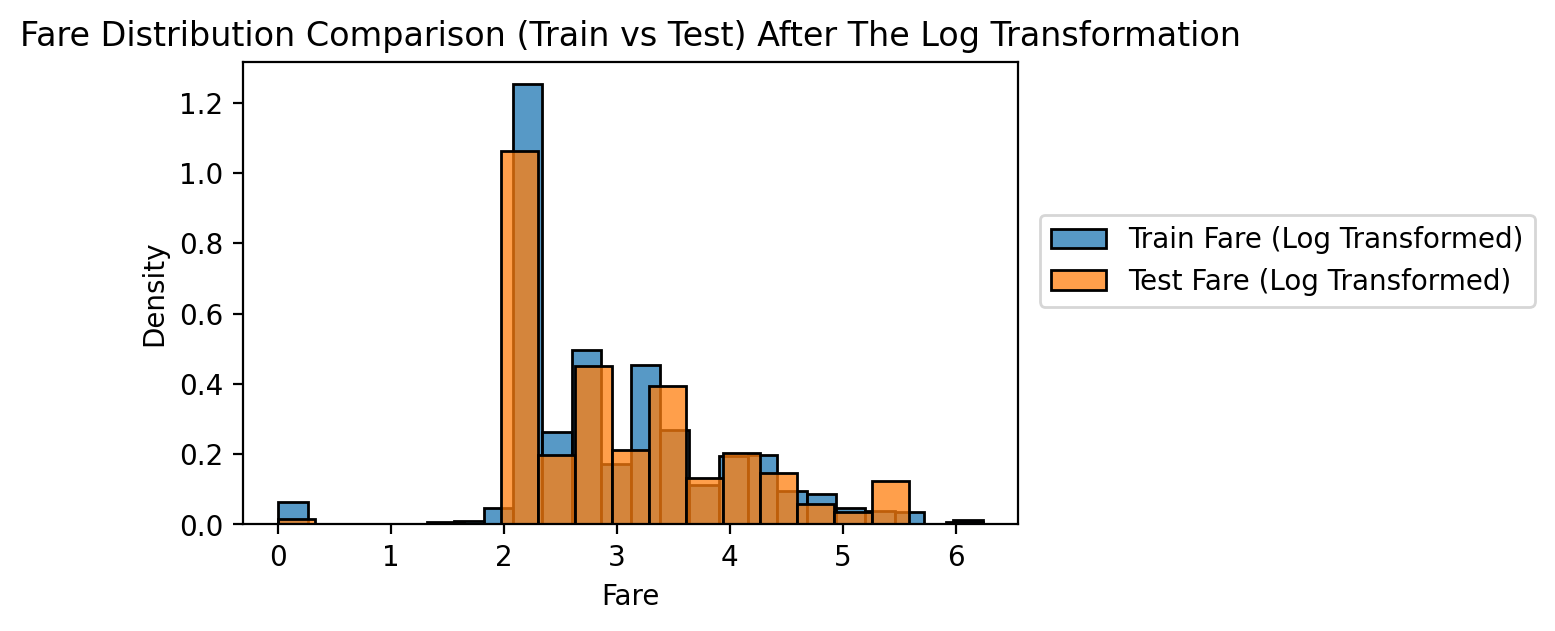

In [24]:
# Both the train and test set displayed heavy right skewness (>1) so I will apply a log transformation to both.

train['Fare'] = np.log1p(train['Fare'])
test['Fare'] = np.log1p(test['Fare'])

#Distribution visual after transformation

fig, ax = plt.subplots(figsize=(5,3),dpi=200)
sns.histplot(train['Fare'],stat = 'density',label = 'Train Fare (Log Transformed)')
sns.histplot(test['Fare'],stat = 'density',label = 'Test Fare (Log Transformed)')
ax.set_title('Fare Distribution Comparison (Train vs Test) After The Log Transformation')
ax.legend(bbox_to_anchor=(1.01,0.7))

#Numerical confirmation : (train set sits between [-0.5,0.5] which is fairly symmetrical, the test set is still moderately right-skewed but it is an acceptable improvement , so I will not further transform it)

print(f"Train Fare Skew After Transformation: {train['Fare'].skew():.4f}")
print(f"Test Fare Skew After Transformation: {test['Fare'].skew():.4f}")

**Log Transformation Results:**

Applying the `log1p` transformation has successfully addressed the heavy right-skewness previously observed in the `Fare` column:
* **Visualizations:** The histogram of the log-transformed `Fare` now shows a distribution that is much closer to symmetrical or bell-shaped compared to the original skewed distribution seen during EDA.
* **Skewness Metric:** The numerical skewness values calculated after the transformation are significantly reduced, confirming the visual improvement ( **0.3949** for train, moderately skewed but much improved **(0.8656)** for test). Since the skewness of the test set was significantly imporved to ranges that are acceptable,  I will not perform another transformation even if it is still slightly right-skewed. 

This transformed `Fare` feature is now better prepared for scaling and use in various machine learning models.

# 5. Preprocessing for Modeling


With feature engineering complete, we now perform the final preprocessing steps required to prepare the data for input into machine learning algorithms. This involves converting all features to a numerical format through encoding and then scaling numerical features to a common range. Finally, we'll drop any columns not needed for modeling.



## 5.1 Encoding Categorical Features

First, we convert the final set of categorical features into a numerical format using One-Hot Encoding with `pandas.get_dummies`. This creates new boolean (`True`/`False`) columns for each category, representing the presence (`True`) or absence (`False`) of that category. These boolean columns function numerically like binary `0`/`1` inputs for machine learning models. We use `drop_first=True` to avoid redundancy. We also align the columns between the train and test sets using `.reindex()` to ensure consistency. Since `Survived` exists in the training columns used for alignment reference, it gets added to the test set (filled with 0s) during reindex, so we explicitly drop it from the test set immediately after.

In [25]:
#Encoding our data

#First our categorical columns

cat_cols = ['Sex','Embarked','Pclass','Title','Ticket_Character_Group','Cabin_Character_Group','Cabin_Multiple']

train_encoded = pd.get_dummies(train, columns = cat_cols, drop_first = True, dummy_na = False)
test_encoded = pd.get_dummies(test, columns = cat_cols, drop_first = True, dummy_na = False)

#Aligning columns

test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

#Assign back

train = train_encoded
test = test_encoded

#We have to remove the 'Survived' column from the reindex call we did in the Aligning columns step.

test = test.drop(columns=['Survived'])

#Columns after encoding

print("Train Dataset Columns after encoding :")
print(train.columns)
print("\nTest Dataset Columns after encoding :")
print(test.columns)

#Length of datasets

print(f"\nInitial number of columns(train dataset): {len(train.columns)}")
print(f"Initial number of columns(test dataset): {len(test.columns)}")



Train Dataset Columns after encoding :
Index(['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Ticket_First_Character', 'Cabin_First_Character',
       'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S',
       'Pclass_2', 'Pclass_3', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare', 'Ticket_Character_Group_2', 'Ticket_Character_Group_3',
       'Ticket_Character_Group_A', 'Ticket_Character_Group_C',
       'Ticket_Character_Group_Other', 'Ticket_Character_Group_P',
       'Ticket_Character_Group_S', 'Cabin_Character_Group_C',
       'Cabin_Character_Group_D', 'Cabin_Character_Group_E',
       'Cabin_Character_Group_Other', 'Cabin_Character_Group_n',
       'Cabin_Multiple_1', 'Cabin_Multiple_2'],
      dtype='object')

Test Dataset Columns after encoding :
Index(['PassengerId', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Ticket_First_Character', 'Cabin_First_Character',
       'FamilySize', 'I

The categorical features are now represented by numerical dummy variables, and the train and test sets have aligned feature columns (excluding the target `Survived` which remains only in `train`).

## 5.2 Scaling Numerical Features


Our analysis so far shows that the key numerical features we intend to use – `Age`, `Fare` (log-transformed), and `FamilySize` – have significantly different scales and ranges. For example, `Age` might range up to 80, while `FamilySize` typically contains small integers, and log-transformed `Fare` exists on yet another scale.

Many machine learning algorithms are sensitive to the scale of input features. Algorithms that use distance calculations (like K-Nearest Neighbors, Support Vector Machines) or rely on gradient descent optimization (like Logistic Regression, Neural Networks) can be heavily influenced by features with larger ranges or variances. These larger-scale features might dominate the learning process, potentially leading to slower convergence or suboptimal model performance, simply because of their scale, not necessarily their importance.

To address this and ensure all numerical features contribute more equally to the model learning process, we will apply **feature scaling**. Specifically, we will use **Standardization** via scikit-learn's `StandardScaler`.

**StandardScaler** transforms each numerical feature by:
1.  Subtracting its **mean** (calculated from the training data).
2.  Dividing by its **standard deviation** (calculated from the training data).

This process results in features that have a mean of approximately 0 and a standard deviation of approximately 1.

**Crucially**, we will **fit** the `StandardScaler` **only on the training data** (`X_train`) to learn the mean and standard deviation. We then use this *same fitted scaler* to **transform both the training data and the test data** (`X_test`). This ensures that the test data is scaled consistently according to the characteristics of the training data, preventing any data leakage from the test set into the scaling process.



In [26]:
#Our numerical columns

num_cols = ['Age','Fare','FamilySize']

#We have to convert the original dtypes to float64 or pandas issues a FutureWarning

for col in num_cols:
    if col in train.columns:
        train[col] = train[col].astype(np.float64)
    if col in test.columns:
        test[col] = test[col].astype(np.float64)

#Scaling with StandardScaler

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train.loc[:,num_cols] = scaler.fit_transform(train[num_cols])
test.loc[:,num_cols] = scaler.transform(test[num_cols])

#Checking the scaled ds

print("Descriptive Statistics after Scaling (train dataset):")
print(train[num_cols].describe().transpose())
print('\nDescriptive Statistics after Scaling (test dataset):')
print(test[num_cols].describe().transpose())

Descriptive Statistics after Scaling (train dataset):
            count          mean       std       min       25%       50%  \
Age         891.0  2.232906e-16  1.000562 -2.253155 -0.592481  0.000000   
Fare        891.0 -1.913920e-16  1.000562 -3.058578 -0.800232 -0.231661   
FamilySize  891.0 -2.392400e-17  1.000562 -0.560975 -0.560975 -0.560975   

                 75%       max  
Age         0.407926  3.870872  
Fare        0.519864  3.385294  
FamilySize  0.059160  5.640372  

Descriptive Statistics after Scaling (test dataset):
            count      mean       std       min       25%       50%       75%  \
Age         418.0  0.035052  0.972446 -2.272394 -0.515526  0.000000  0.465642   
Fare        418.0  0.053583  0.999123 -3.058578 -0.801924 -0.231661  0.534977   
FamilySize  418.0 -0.040240  0.942029 -0.560975 -0.560975 -0.560975  0.059160   

                 max  
Age         3.563054  
Fare        3.385294  
FamilySize  5.640372  


The numerical features have been scaled successfully, as indicated by the mean (**~0**) and standard deviation (**~1**) in the training set's descriptive statistics.

### 5.3 Dropping Unnecessary Columns

Finally, we perform a cleanup by dropping the original or intermediate columns that are no longer required for modeling (`'PassengerId'`,`'Name'`,`'SibSp'`,`'Parch'`,`'Ticket'`,`'Cabin'`,`'Cabin_First_Character'`,`'Ticket_First_Character'`), as their information is now captured in the engineered and processed features (`'Cabin_Character_Group'`,`'Ticket_Character_Group'`,`'Title'`,`'FamilySize'`,`'IsAlone'`). We store the `PassengerId` from the test set beforehand, as it's needed for the final submission file.

In [27]:
# Let's drop the columns we no longer need

# We need the test passenger ids for the submission file
test_pass_ids = test['PassengerId']

cols_to_drop = ['PassengerId','Name','SibSp','Parch','Ticket','Cabin','Cabin_First_Character','Ticket_First_Character']

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)
#Check
print(f"Final Columns of the train dataset:{train.columns}")

print(f"\nFinal Columns of the test dataset:{test.columns}")

print(f"\nFinal number of columns(train dataset): {len(train.columns)}")
print(f"Final number of columns(test dataset): {len(test.columns)}")

print("\n"f"Final train dataset shape: {train.shape}")
print(f"Final test dataset shape: {test.shape}")

Final Columns of the train dataset:Index(['Survived', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male',
       'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3', 'Title_Miss',
       'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Ticket_Character_Group_2',
       'Ticket_Character_Group_3', 'Ticket_Character_Group_A',
       'Ticket_Character_Group_C', 'Ticket_Character_Group_Other',
       'Ticket_Character_Group_P', 'Ticket_Character_Group_S',
       'Cabin_Character_Group_C', 'Cabin_Character_Group_D',
       'Cabin_Character_Group_E', 'Cabin_Character_Group_Other',
       'Cabin_Character_Group_n', 'Cabin_Multiple_1', 'Cabin_Multiple_2'],
      dtype='object')

Final Columns of the test dataset:Index(['Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q',
       'Embarked_S', 'Pclass_2', 'Pclass_3', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Ticket_Character_Group_2',
       'Ticket_Character_Group_3', 'Ticket_Character_Group_A',
       'Ticket_Character_Gr

**Preprocessing Complete:**

Unnecessary columns have been dropped, and the `train` and `test` DataFrames contain the final set of numerical features (including scaled and one-hot encoded features) ready for model training. The `train` DataFrame includes the `Survived` target column, while the `test` DataFrame does not. 

Our next and final step before submitting our results is **Model Creation**.

# **6. Model Building and Evaluation**



With the data cleaning, feature engineering, encoding, and scaling phases complete, our dataset is now prepared for machine learning. We will now:

1. Separate the features (predictor variables) from the target variable (`Survived`) in our training data.
2. Train various classification models.
3. Evaluate their performance using cross-validation.
4. Select the best model and generate predictions for the test set.



## 6.1 Separating Features (X) and Target (y)

Before feeding data into scikit-learn models, we need to explicitly define our input features (conventionally named `X`) and the target variable we want to predict (conventionally named `y`).

* **`X_train`**: Will contain all columns from the processed `train` DataFrame *except* `Survived`.
* **`y_train`**: Will contain *only* the `Survived` column from the `train` DataFrame.
* **`X_test`**: Will be the processed `test` DataFrame, which already contains only the features needed for prediction.



In [28]:

#Separation of X,y and x_test

X_train = train.drop(columns=['Survived'])
y_train = train['Survived']
X_test = test

#Split Shapes

print("Shapes of the resulting data splits:")
print(f"X_train shape: {X_train.shape}") 
print(f"y_train shape: {y_train.shape}")  
print(f"X_test shape: {X_test.shape}")   

#Check to identify potential mismatch

if list(X_train.columns) == list(X_test.columns):
    print("\nFeature columns in X_train and X_test match.")
else:
    print("\nWARNING: Feature columns mismatch between X_train and X_test!")

Shapes of the resulting data splits:
X_train shape: (891, 27)
y_train shape: (891,)
X_test shape: (418, 27)

Feature columns in X_train and X_test match.


**Data Separation Finalized:**

The data has been successfully divided into training features (`X_train`), training target (`y_train`), and test features (`X_test`). The shapes confirm the number of samples and features in each set. Crucially, `X_train` and `X_test` have the same number of columns, ensuring consistency for model prediction.

We are now ready to start training and evaluating classification models using `X_train` and `y_train`.

## 6.2 Model Training & Tuning: Logistic Regression


Now that the data is prepared, we can start training and evaluating different classification models. The strategy is to try several algorithms, tune their hyperparameters using cross-validation, and compare their performance to select the best one for final predictions.

We begin with **Logistic Regression**, a widely used linear model for binary classification tasks that estimates probabilities using a logistic function. While relatively simple, its performance can be sensitive to **regularization**, which helps prevent overfitting. We will use `GridSearchCV` to find the optimal regularization settings.

The key hyperparameters we tune are:
* `C`: The inverse of regularization strength (smaller values mean stronger regularization). We test a range of values.
* `penalty`: The type of regularization ('l1' or 'l2').
* `solver`: We fix this to `'liblinear'`, which is efficient for this dataset size and supports both L1 and L2 penalties.
* `max_iter`: Set high enough to ensure convergence.

`GridSearchCV` will test all combinations using 5-fold cross-validation and identify the one yielding the highest accuracy.

In [29]:
#I want to test the performance of many models and compare them to eachother, I will use GridSearchCV to make the process more simple and find the best parameters for each model

#Let's start with Logistic Regression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state = 42)

#Setting up GridSearchCV

param_grid_lr = {
              'max_iter' : [2000],
              'C': [0.01, 0.1, 1, 3, 5, 10, 50, 100],
              'penalty' :['l1','l2'],
              'solver' : ['liblinear'],
               }

from sklearn.model_selection import GridSearchCV

grid_search_lr = GridSearchCV(estimator=lr, 
                           param_grid = param_grid_lr, 
                           scoring = 'accuracy', 
                           n_jobs = -1, 
                           verbose = 1)

#Fitting

grid_search_lr.fit(X_train,y_train)
best_lr_model = grid_search_lr.best_estimator_

#Results

print(f"\nBest Mean Cross-Validation Accuracy Score:")
print(f"{grid_search_lr.best_score_:.4f}")

print("\nBest estimator:")
print(best_lr_model)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Mean Cross-Validation Accuracy Score:
0.8238

Best estimator:
LogisticRegression(C=5, max_iter=2000, random_state=42, solver='liblinear')


**Logistic Regression Tuning Results:**


* **Best CV Score:** The output shows the highest mean accuracy achieved **0.8238** across the cross-validation folds for the best parameter combination found. This score serves as our performance estimate for tuned Logistic Regression.
* **Best Estimator:** The printed model parameters show the specific values for `C`, `penalty`, `solver`, and `max_iter` that resulted in the best cross-validation score. The `best_lr_model` variable now holds this optimized model, automatically refit on the entire training set. In our case the Best Linear Regression Model was :
   **LogisticRegression(C=5, max_iter=2000, random_state=42, solver='liblinear')**

We will record this best score and compare it with other models later. Next, we will apply the same tuning process to a different algorithm : Random Forest.

## 6.3 Model Training & Tuning: Random Forest


Next, we train and evaluate a **Random Forest Classifier**. Random Forest is a powerful ensemble learning method that operates by constructing multiple decision trees during training. For classification tasks, the output is the class selected by most trees. This approach typically improves accuracy and controls overfitting compared to a single decision tree but requires more computing power, resulting in longer training times.

We will use `GridSearchCV` again to optimize its hyperparameters for accuracy using 5-fold cross-validation. Key hyperparameters for Random Forest include:
* `n_estimators`: The number of trees to build in the forest.
* `max_depth`: The maximum depth allowed for each individual tree.
* `min_samples_split`: The minimum number of samples required before a node is split.
* `min_samples_leaf`: The minimum number of samples allowed in a leaf node.
* `max_features`: The number of features to consider when looking for the best split.



In [30]:
#Let's try RandomForest next

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=42)

#Setting up GridSearchCV

param_grid_rfc = { 'n_estimators':[100,200,300],
                   'max_depth':[5,10,None],
                   'min_samples_split':[2,5,10],
                   'min_samples_leaf':[1,3,5],
                   'max_features':['sqrt','log2']}

grid_search_rfc = GridSearchCV(estimator = rfc,
                               param_grid = param_grid_rfc,
                               scoring = 'accuracy',
                               n_jobs = -1,
                               verbose = 1)
#Fitting 

grid_search_rfc.fit(X_train,y_train)
best_rfc_model = grid_search_rfc.best_estimator_

#Results

print(f"\nBest Mean Cross-Validation Accuracy Score:")
print(f"{grid_search_rfc.best_score_:.4f}")

print("\nBest Estimator:")
print(best_rfc_model)

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best Mean Cross-Validation Accuracy Score:
0.8462

Best Estimator:
RandomForestClassifier(min_samples_split=10, n_estimators=300, random_state=42)


**Random Forest Tuning Results:**

* **Best CV Score:** The reported mean cross-validation accuracy **0.8462** represents the estimated performance of this tuned Random Forest. It is higher than the score achieved by Logistic Regression for this dataset.
* **Best Estimator:** Our best model was : **RandomForestClassifier(min_samples_split=10, n_estimators=300, random_state=42)** 

We will now proceed to evaluate the algorithm XGBoost.

## 6.4 Model Training & Tuning: XGBoost Classifier


Now we explore Gradient Boosting Machines (GBMs), another type of powerful ensemble method. Unlike Random Forest (which builds trees independently in parallel), GBMs build trees sequentially, where each new tree tries to correct the errors made by the ensemble so far. We will use **XGBoost (Extreme Gradient Boosting)**, a highly optimized and popular GBM implementation known for its speed and performance, often including built-in regularization.


To find an optimal configuration for `XGBClassifier` on our data, we will again use `GridSearchCV` to tune several key hyperparameters using 5-fold cross-validation, optimizing for accuracy. The parameters we will explore are:

* **`n_estimators`**: The total number of trees (boosting rounds) to build. More trees can improve performance up to a point, but too many can lead to overfitting or diminishing returns, while also increasing computation time.
* **`max_depth`**: The maximum depth allowed for each individual decision tree. This directly controls the complexity of each tree learner. Deeper trees can capture more complex feature interactions but risk overfitting; shallower trees are simpler and more regularized but might underfit. GBMs often perform well with relatively shallow trees (e.g., 3-8).
* **`learning_rate` (also called `eta`)**: This shrinks the contribution of each new tree added to the ensemble. Smaller values (e.g., 0.05, 0.1) make the boosting process more conservative, requiring more trees (`n_estimators`) but often leading to better generalization. Higher values speed up convergence but increase the risk of overshooting the optimal solution.
* **`subsample`**: The fraction of the training data instances to be randomly sampled for building each tree. Using a value less than 1.0 introduces randomness (Stochastic Gradient Boosting), which helps prevent overfitting by ensuring each tree sees a slightly different subset of the data.
* **`colsample_bytree`**: The fraction of features (columns) to be randomly sampled when constructing each tree. Similar to `subsample`, this adds randomness, reduces correlations between trees, and helps prevent overfitting, especially if there are many features.
* **`gamma` (also called `min_split_loss`)**: A regularization parameter. It specifies the minimum reduction in the loss function required to make a split in a tree node. Larger values make the algorithm more conservative, leading to simpler trees with fewer splits, thus preventing overfitting.



In [31]:
#Next are boosting algorithms, I will implement XGBoost or Xtreme Gradient Boosting

from xgboost import XGBClassifier

xgb = XGBClassifier(objective = 'binary:logistic',
                    use_label_encoder=False,
                    random_state = 42)
#GridSearchCV

param_grid_xgb = {'n_estimators': [100,200],
                  'max_depth': [3,5],
                  'learning_rate': [0.1,0.2],
                  'subsample': [0.7, 0.8, 0.9],
                  'colsample_bytree': [0.7, 0.8, 0.9],
                  'gamma': [0, 0.1, 0.2] }

grid_search_xgb = GridSearchCV(estimator = xgb,
                               param_grid = param_grid_xgb,
                               cv = 5,
                               scoring = 'accuracy',
                               n_jobs = -1,
                               verbose = 1)
                    
#Fitting

grid_search_xgb.fit(X_train,y_train)
best_xgb_model = grid_search_xgb.best_estimator_

#Results

print(f"\nBest Mean Cross-Validation Accuracy Score:")
print(f"{grid_search_xgb.best_score_:.4f}")

print("\nBest Estimator:")
print(best_xgb_model)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Mean Cross-Validation Accuracy Score:
0.8473

Best Estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.1, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)


**XGBoost Tuning Results:**



* **Best CV Score:** The reported "Best Mean Cross-Validation Accuracy Score" **0.8473**  provides the performance estimate for this tuned XGBoost model. This score is higher than both Logistic Regression (**0.8238**) and Random Forest (**0.8462**).
* **Best Estimator:** Our best XGBoost model was : XGBClassifier( n_estimators=100, max_depth=5, learning_rate=0.1, 
The `best_xgb_model` variable now holds this optimized XGBoost model, refit on the full training data. We'll continue evaluating other models or refine this one further.

## 6.5 Model Training & Tuning: Support Vector Classifier (SVC)


We now try a different class of algorithm: **Support Vector Machines (SVM)**, using the **Support Vector Classifier (`SVC`)**. SVMs work by finding the optimal hyperplane (or decision boundary) that best separates the data points belonging to different classes, aiming to maximize the margin between the classes.

For non-linear relationships, SVMs use the "kernel trick". We will primarily test the **Radial Basis Function (`rbf`) kernel**, which is effective at capturing complex patterns by mapping data to a higher-dimensional space. The performance of `SVC` is highly dependent on its hyperparameters and benefits significantly from feature scaling (which we have already done). We will tune:

* **`C`**: The regularization parameter. It trades off correct classification of training examples against maximization of the decision boundary's margin. A **smaller `C`** creates a wider margin but might tolerate more misclassifications (more regularization). A **larger `C`** pushes for fewer misclassifications, potentially leading to a narrower margin and overfitting.
* **`gamma`**: Specific to the 'rbf' kernel, it defines the influence radius of a single training example. **Low `gamma`** means a broader influence (smoother decision boundary, potentially underfitting), while **high `gamma`** means a closer influence (more complex boundary, potentially overfitting). We test default values (`'scale'`, `'auto'`) and specific numbers.
* **`kernel`**: We will focus on `'rbf'` in this grid search.

We set `probability=True` to enable probability predictions later, though this slows down training. `GridSearchCV` will find the best `C` and `gamma` combination for the 'rbf' kernel based on 5-fold cross-validation accuracy. Note that SVM tuning can sometimes be computationally intensive.

In [32]:
#Next up is SupportVectorClassifier or SVC

from sklearn.svm import SVC

svc = SVC(probability = True, 
         random_state = 42)

#GridSearchCV

param_grid_svc = {'C': [0.1, 1, 5, 10, 50, 100],
                  'gamma': ['scale', 'auto', 0.1, 1, 5, 10],
                  'kernel': ['rbf'] }

grid_search_svc = GridSearchCV(estimator = svc,
                               param_grid = param_grid_svc,
                               cv = 5,
                               scoring = 'accuracy',
                               n_jobs = -1,
                               verbose = 1)

#Fitting

grid_search_svc.fit(X_train,y_train)
best_svc_model = grid_search_svc.best_estimator_

#Results

print(f"\nBest Mean Cross-Validation Accuracy Score:")
print(f"{grid_search_svc.best_score_:.4f}")

print("\nBest estimator:")
print(best_svc_model)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Mean Cross-Validation Accuracy Score:
0.8350

Best estimator:
SVC(C=10, gamma='auto', probability=True, random_state=42)


**SVC Tuning Results:**


* **Best CV Score:** The "Best Mean Cross-Validation Accuracy Score":  **0.8350** represents the estimated generalization performance of the tuned SVC model. It performed better than Logistic Regression but scored lower than both XGBoost and Random Forest models.
* **Best Estimator:** Our best SVC model was : **SVC(C=10, gamma='auto', probability=True, random_state=42)**



## 6.6 Model Training & Tuning: K-Nearest Neighbors (KNN)


Next, we try the **K-Nearest Neighbors (`KNeighborsClassifier`)** algorithm. KNN is fundamentally different from the previous models; it's an *instance-based* or *lazy learning* algorithm. It doesn't learn an explicit model function during training but instead stores the entire training dataset. To make a prediction for a new point, it finds the 'k' closest points (neighbors) in the training data based on a distance metric and assigns the most frequent class among those neighbors.

Effective use of KNN heavily relies on **feature scaling**, as distance calculations are sensitive to the range of features. We have already scaled our numerical features using `StandardScaler`, making the data suitable for KNN.

We will use `GridSearchCV` to tune the key hyperparameters:
* **`n_neighbors` ('k')**: The number of neighbors to consider for the majority vote.
* **`weights`**: How the votes of neighbors are weighted ('uniform' gives equal weight, 'distance' gives more weight to closer neighbors).
* **`metric` / `p`**: The distance metric used ('euclidean', 'manhattan', which correspond to p=2 and p=1 for the default 'minkowski' metric).
* **`algorithm`**: The underlying algorithm used to efficiently find neighbors ('auto', 'ball_tree', 'kd_tree').



In [33]:
#K-Nearest Neighbors or KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

#GridSearchCV

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm' : ['auto', 'ball_tree','kd_tree'],
    'p' : [1,2]}

grid_search_knn = GridSearchCV(estimator = knn,
                               param_grid = param_grid_knn,
                               cv = 5,
                               scoring = 'accuracy',
                               n_jobs = -1,
                               verbose = 1)

#Fitting

grid_search_knn.fit(X_train,y_train)
best_knn_model = grid_search_knn.best_estimator_

#Results

print(f"\nBest Mean Cross-Validation Accuracy Score:")
print(f"{grid_search_knn.best_score_:.4f}")

print("\nBest estimator:")
print(best_knn_model)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Mean Cross-Validation Accuracy Score:
0.8215

Best estimator:
KNeighborsClassifier(metric='euclidean', p=1)


**KNN Tuning Results:**


* **Best CV Score:** The "Best Mean Cross-Validation Accuracy Score": **0.8215** indicates the estimated performance of this tuned KNN model. It is the worst performing model we have tested so far.
* **Best Estimator:** Our best KNN model was : **KNeighborsClassifier(metric='euclidean', p=1)**

 **Note:** KNN doesn't explicitly 'train' in the same way as other models, but `best_knn_model` holds the settings of the best performing KNN model and knows the training data.

## 6.7 Model Training & Evaluation: Gaussian Naive Bayes (GNB)


As a final model for comparison, we evaluate the **Gaussian Naive Bayes (`GaussianNB`)** classifier. This algorithm is based on Bayes' Theorem and makes a "naive" assumption of conditional independence between features given the class label. It also assumes feature likelihoods follow a Gaussian distribution.

`GaussianNB` is computationally very fast and often serves as a good **baseline model**. It typically doesn't require hyperparameter tuning, so instead of `GridSearchCV`, we evaluate its performance directly using `cross_val_score` with 5 folds to get an estimate of its accuracy on our processed data.

In [34]:
#Finally let's try Gaussian Naive Bayes or GaussianNB

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score # We use cross_val_score as there is no grid search needed

gnb = GaussianNB()

#CrossValidation

cv_scores_gnb = cross_val_score(gnb, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

#Results

print("\nCross-Validation Results (GaussianNB)")
print("Accuracy Scores per fold:")
print(cv_scores_gnb)
print(f"\nMean Accuracy from CV: {np.mean(cv_scores_gnb):.4f}")
print(f"Standard Deviation from CV: {np.std(cv_scores_gnb):.4f}")


Cross-Validation Results (GaussianNB)
Accuracy Scores per fold:
[0.70949721 0.63483146 0.76966292 0.76404494 0.8258427 ]

Mean Accuracy from CV: 0.7408
Standard Deviation from CV: 0.0645


**Gaussian Naive Bayes (GNB) Evaluation Results:**


* **Performance:** The mean cross-validation accuracy  **0.7408** gives us the estimated performance for this baseline model. It expectedly replaces KNN as the worst performing model, given the simplicity of the GNB algorithm and the low computational costs it requires.
* **Stability:** The standard deviation **(0.0645)** across the folds indicates the consistency of the performance on different subsets of the training data.



## 6.8 Model Training & Evaluation: Refining XGBoost


We have now trained and evaluated the algorithmic models of Logistic Regression, Random Forest, XGBoost, SVC, KNN, and GaussianNB. Reviewing the cross-validation scores obtained so far, we can attempt one final optimization pass on the most promising candidate before making our final model selection.

Given XGBoost's strong initial CV performance, we will perform a second, more refined `GridSearchCV`. This search will use a narrower parameter grid, focused around the best hyperparameters identified in the first XGBoost run. The aim is to see if fine-tuning within this promising region can yield further improvement in the cross-validation score.

**However**, it's important to address that chasing small improvements in CV scores through extensive tuning can potentially lead to **overfitting** to the training data, which while improving the CV score metric, might actually perform worse on unseen data (submission leaderboard). 

In [35]:
#I want to try and improve XGBoost as it is our best performing model.I will tune close to it's best parameters, though this will probably cause the model to overfit to the training data.



xgb_refined = XGBClassifier(objective = 'binary:logistic',
                            use_label_encoder=False,
                            random_state = 42,
                            eval_metric='logloss')

param_grid_xgb_refined =  {'n_estimators': [90,100,110],         
    'max_depth': [4, 5, 6],             
    'learning_rate': [0.08, 0.1, 0.12],  
    'subsample': [0.6, 0.7, 0.8],             
    'colsample_bytree': [0.6, 0.7, 0.8],      
    'gamma': [0.08, 0.1, 0.12]  }

grid_search_xgb_refined = GridSearchCV(estimator=xgb_refined,
                                    param_grid=param_grid_xgb_refined,
                                    cv=5,
                                    scoring='accuracy',
                                    n_jobs=-1,
                                    verbose=1)

#Fitting
grid_search_xgb_refined.fit(X_train,y_train)
best_xgb_refined_model = grid_search_xgb_refined.best_estimator_

#Results
print("Previous Best XGBoost Parameters:", grid_search_xgb.best_params_)
print(f"Previous Best CV Score: {grid_search_xgb.best_score_:.4f}")
print("\nNew Best XGBoost Parameters:", grid_search_xgb_refined.best_params_)
print(f"New Best CV Score: {grid_search_xgb_refined.best_score_:.4f}")


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Previous Best XGBoost Parameters: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Previous Best CV Score: 0.8473

New Best XGBoost Parameters: {'colsample_bytree': 0.7, 'gamma': 0.12, 'learning_rate': 0.12, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6}
New Best CV Score: 0.8518


**Refined XGBoost Tuning Results:**


* **Previous Best XGBoost Parameters :** The best parameters of the initial XGBoost model : **{'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}**
* **Previous Best CV Score :** The Mean CV Score of the initial XGBoost model : **0.8473**

* **New Best XGBoost Parameters:** **{'colsample_bytree': 0.7, 'gamma': 0.12, 'learning_rate': 0.12, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.6}** . We can confirm that only `colsample_bytree` and `n_estimators` kept their initial values , all other parameters were adjusted in our Refined XGBoost model
* **New Best CV Score:**  **0.8518** Our new CV Score is indeed higher than the previous **0.8473** but by a very small margin. To be exact, it is scoring only **0.53%** higher 

**Test Comparison:** While a slightly improved CV score was achieved here, the same pattern wasn't followed in the test submission. The refined model actually performed slightly *worse* on the public leaderboard **(0.77033)** than the original tuned XGBoost model **(0.77511)** , suggesting potential overfitting to the CV process during refinement.



# **7. Exploring Ensemble Methods (Simple Averaging)**

After tuning individual models, Random Forest emerged as the best performer on the public leaderboard (LB Score: **0.78468**), with the original XGBoost also showing reasonable performance (LB Score: **0.77511**). A common strategy to potentially improve robustness and accuracy further is **ensembling**, which combines predictions from multiple models.

We will try a simple ensembling technique: **averaging the predicted probabilities** from our two best leaderboard models (Random Forest and the original XGBoost). We assign equal weight (50/50) to each model's probability prediction and then threshold the resulting average probability at 0.5 to get the final classification.

**Note:** I also experimented with weighted averaging (giving higher weight to the Random Forest model) with multiple weight values, but simple averaging yielded the best score among the ensemble attempts so I will only include its code.

In [36]:
#Let's try ensembling the 2 best performing models (RandomForest,Original XGBoost) by averaging the probabilities of their predictions.

#Probabilities prediction

probs_rfc = best_rfc_model.predict_proba(X_test)[:,1]
probs_xgb = best_xgb_model.predict_proba(X_test)[:,1]

#Averaging these probabilities

avg_probs = (probs_rfc + probs_xgb)/2.0

#Making Ensemble predictions

ensemble_pred = (avg_probs >= 0.5).astype(int)



**Simple Averaging Ensemble Explanation:**

  * **Probability Extraction:** First, for each model (`best_rfc_model`, `best_xgb_model`), we used `.predict_proba(X_test)[:, 1]` to get an array containing the predicted probability of survival (a value between 0.0 and 1.0) for every passenger in the test set.
  * **Averaging:** The line `avg_probs = (probs_rfc + probs_xgb) / 2.0` calculates the simple arithmetic mean of the survival probabilities predicted by the two models for each passenger. The resulting `average_probs` array holds values between 0.0 and 1.0, representing the combined probabilistic prediction of the ensemble.
  * **Thresholding:** To arrive at a final binary classification (0 or 1), we apply a standard decision threshold of 0.5 to the averaged probabilities. The code `ensemble_pred = (average_probs >= 0.5).astype(int)` achieves this:
    * `(avg_probs >= 0.5)` creates a boolean array (`True` where the average probability is 0.5 or higher, `False` otherwise).
    * `.astype(int)` converts `True` to `1` (Survived) and `False` to `0` (Died).




# **8. Submission File Generation and Results**



## 8.1 File Generation
Having completed the model training, tuning, and evaluation process, the final step is to generate the prediction files in the correct format for submission to the Kaggle competition.The following code will generate submission files for every model we have prepared, including the simple ensemble attempt.The required format according to the rules of the competition is a CSV file containing only the `PassengerId` and the predicted `Survived` (0 or 1) columns.

In [37]:
#We have to fit the gnb model :
gnb_model = gnb.fit(X_train, y_train)


#Our list of models excluding the ensemble:

models_to_submit = {
    'logreg': best_lr_model,
    'rfc': best_rfc_model,
    'xgb_orig': best_xgb_model, 
    'xgb_refined': best_xgb_refined_model,       
    'svc': best_svc_model,
    'knn': best_knn_model,
    'gnb': gnb_model} 

#Generating file for our models

for name, model in models_to_submit.items():
    predictions = model.predict(X_test)
    
    submission_df = pd.DataFrame({
        'PassengerId': test_pass_ids,
        'Survived': predictions.astype(int)})
    
    submission_filename = f'titanic_submission_{name}.csv'
    submission_df.to_csv(submission_filename, index=False) #index=False is required by the competition rules

#Generating file for the ensemble method

submission_df_ensemble = pd.DataFrame({
    'PassengerId': test_pass_ids,
    'Survived': ensemble_pred})

submission_filename_ensemble = 'titanic_submission_ensemble_avg.csv'
submission_df_ensemble.to_csv(submission_filename_ensemble, index=False)


## 8.2 Final Results 

Finally, I will group our findings into a dataframe so we can directly identify the best and worst performers of the models we created and tested.

In [38]:
#Let's create a DataFrame to compare our best models directly

model_comparison_data = {'Model' : [
                           'Logistic Regression',
                            'Random Forest',
                            'XGBoost',
                            'Refined XGBoost',
                            'SVC',
                            'KNN',
                            'GaussianNB',
                            'Ensemble'],
                        'Mean CV Accuracy' : [
                            grid_search_lr.best_score_,     
                            grid_search_rfc.best_score_,   
                            grid_search_xgb.best_score_,
                            grid_search_xgb_refined.best_score_,
                            grid_search_svc.best_score_, 
                            grid_search_knn.best_score_,  
                            np.mean(cv_scores_gnb),
                            np.nan],
                        'Leaderboard Score': [
                            0.76555,
                            0.78468,
                            0.77511,
                            0.77033,
                            0.77272,
                            0.75119,
                            0.73923,
                            0.78229]}
                        
                         
                                                                         
results = pd.DataFrame(model_comparison_data)
results = results.sort_values(by='Leaderboard Score',ascending=False).reset_index(drop=True)

print("Model Performance Comparison")
print(results)

Model Performance Comparison
                 Model  Mean CV Accuracy  Leaderboard Score
0        Random Forest          0.846237            0.78468
1             Ensemble               NaN            0.78229
2              XGBoost          0.847348            0.77511
3                  SVC          0.835007            0.77272
4      Refined XGBoost          0.851849            0.77033
5  Logistic Regression          0.823796            0.76555
6                  KNN          0.821549            0.75119
7           GaussianNB          0.740776            0.73923


**Final Model Comparison:**

* **CV vs. Leaderboard Discrepancy:** A noticeable gap exists between cross-validation accuracy (estimated on training data) and the actual scores achieved on the Kaggle public leaderboard (calculated on unseen test data). For instance, the refined XGBoost model achieved the highest CV score **(0.8518)** but did not perform best on the leaderboard.
* **Top Leaderboard Performance:** The **tuned Random Forest classifier** yielded the highest public leaderboard score among all tested single models and simple ensembles, achieving **0.78468**.
* **Ensemble Results:** Simple probability averaging of Random Forest and the original XGBoost resulted in a score **(0.78229)** slightly below the best single Random Forest model.

# **9. Conclusion and Final Selection**


This project aimed to apply various data science techniques to predict passenger survival on the RMS Titanic, based on the classic Kaggle dataset. The process involved several key stages:

1.  **Exploratory Data Analysis (EDA):** We began by loading and inspecting the data, identifying missing values (in `Age`, `Cabin`, `Embarked`), analyzing the distributions of numerical features , examining the frequencies of categorical features (`Sex`, `Pclass`, `Embarked`), and looking at initial correlations with the `Survived` target variable.
2.  **Feature Engineering:** Based on EDA insights, we created new features to better capture potentially predictive information. This included extracting `Title` from `Name`, creating `FamilySize` and `IsAlone` from `SibSp`/`Parch`, and deriving `Cabin_Character_Group` (handling missing cabins and grouping rare decks) and `Ticket_Character_Group` (grouping rare prefixes) to manage high cardinality. We also engineered `Cabin_Multiple`. Missing values in `Age`, `Embarked`, and `Fare` were imputed.
3.  **Preprocessing for Modeling:** Categorical features were one-hot encoded using `pd.get_dummies` (`drop_first=True`), and key numerical features (`Age`, log-transformed `Fare`, `FamilySize`) were standardized using `StandardScaler`. Unnecessary original/intermediate columns were dropped.
4.  **Model Evaluation & Tuning:** We systematically trained and evaluated several classification models: Logistic Regression, Random Forest, XGBoost (including a refinement attempt), Support Vector Classifier (SVC), K-Nearest Neighbors (KNN), and Gaussian Naive Bayes (GNB). `GridSearchCV` with 5-fold cross-validation (optimizing for accuracy) was used to tune hyperparameters for the relevant models. Simple ensembling (probability averaging) was also explored.


**Final Model Choice:**

Given the goal of maximizing predictive accuracy on unseen data as measured by the Kaggle competition leaderboard, the **Random Forest model** (using the hyperparameters identified via `GridSearchCV`) with a score of **0.78468 (top 15%)** is selected as the best-performing model from this analysis.


**Potential Future Improvements:**

Further work could involve exploring more sophisticated feature engineering (e.g., interaction terms, target encoding), trying other algorithms like LightGBM or CatBoost, implementing advanced ensembling techniques (stacking/blending), or performing deeper error analysis on model predictions.

This project demonstrates a complete machine learning workflow, highlighting the importance of thorough EDA, careful feature engineering, robust model evaluation, and iterative refinement.